Importing required library and functions

In [ ]:
import sys
import os
import re
import shutil
import psutil
import platform
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt;
import pyemu
import flopy
#assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
# herebedragons.py contains a series of utility functions that help us 
sys.path.insert(0,"..")
import herebedragons as hbd
from scipy.interpolate import griddata, RegularGridInterpolator
import skgstat as skg
import glob

Setting up MODFLOW files dir

Getting executables to run PEST

In [2]:
# folder containing original model files
org_d = os.path.join('..', '..', '..', "results")

# a dir to hold a copy of the org model files
tmp_d = os.path.join('mf6')

if os.path.exists(tmp_d):
    shutil.rmtree(tmp_d)
shutil.copytree(org_d,tmp_d)

sim_folders = glob.glob(f'./{tmp_d}/**/')


for i in sim_folders: 
    # get executables
    hbd.prep_bins(i)
    # get dependency folders
    hbd.prep_deps(i)

hbd.prep_bins(tmp_d)
hbd.prep_deps(tmp_d)

In [3]:
sim_ws = os.path.join('..', '..', '..', "results", "3d_injection_modeling_PMW-6")
os.listdir(tmp_d)

['3d_injection_modeling_PMW-3',
 '3d_injection_modeling_PMW-6',
 'inschek.exe',
 'k_layer1.txt',
 'k_layer2.txt',
 'k_layer3.txt',
 'mf5to6.exe',
 'mf6.exe',
 'mp7.exe',
 'pest.exe',
 'pestchek.exe',
 'pestpp-da.exe',
 'pestpp-glm.exe',
 'pestpp-ies.exe',
 'pestpp-mou.exe',
 'pestpp-opt.exe',
 'pestpp-sen.exe',
 'pestpp-swp.exe',
 'PMW-3_heads.csv',
 'PMW-6_heads.csv',
 'ss_layer1.txt',
 'ss_layer2.txt',
 'ss_layer3.txt',
 'tempchek.exe',
 'zbud6.exe']

Loading MODFLOW simulation to obtain discretization information

In [4]:
template_ws = os.path.join("template")

In [5]:
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_folders[0])
gwf = sim.get_model()

#pyemu.os_utils.run("mf6", cwd=sim_folders[0], verbose=True)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


Spatial reference

In [6]:
#grid_length_x = gwf.dis.delr.array.sum()
grid_length_y = gwf.dis.delc.array.sum()
topleft_yorigin = gwf.dis.yorigin.array + grid_length_y
proj4 = '+proj=utm +zone=15 +datum=NAD83 +units=m +no_defs +type=crs'
sr = pyemu.helpers.SpatialReference(
    delr=gwf.dis.delr.array, 
    delc=gwf.dis.delc.array,
    xul=gwf.dis.xorigin.array, 
    yul=topleft_yorigin, 
    proj4_str=proj4,
)

Instantiate PstFrom

In [7]:
template_ws = os.path.join("template") #template directory (PstFrom working folder)
start_datetime = "08/29/2024"

#instantiate PstFrom
pf = pyemu.utils.PstFrom(  
    original_d = tmp_d, #where the model is stored
    #original_d = '.',
    new_d = template_ws, #where the PEST template will be stored
    longnames = False, #for using PEST/PEST_HP
    spatial_reference = sr, #spatial reference from the model
    zero_based = False, #MODFLOW does not use zero based indices
    start_datetime = start_datetime, #for temporal correlation between parameters
    echo=True, 
    remove_existing=True, #remove existing files in the template directory
)

2026-02-27 14:36:15.370983 starting: opening PstFrom.log for logging
2026-02-27 14:36:15.371981 starting PstFrom process
2026-02-27 14:36:15.382524 starting: setting up dirs
2026-02-27 14:36:15.383515 starting: removing existing new_d 'template'
2026-02-27 14:36:15.707645 finished: removing existing new_d 'template' took: 0:00:00.324130
2026-02-27 14:36:15.707645 starting: copying original_d 'mf6' to new_d 'template'
2026-02-27 14:36:20.769228 finished: copying original_d 'mf6' to new_d 'template' took: 0:00:05.061583
2026-02-27 14:36:20.771228 finished: setting up dirs took: 0:00:05.388704


pf

Adjusting heads.csv file to match field data times

In [8]:
import flopy.utils.binaryfile as bf

def process_modflow_heads(path, well, desired_order):
    """
    Reads the MODFLOW binary heads file, extracts heads for specified
    observation wells at desired times, interpolating between time steps
    if necessary, and saves the data to heads.csv.
    """
    for path, well, desired_order in zip(path, wells, desired_order):

        model_name = "MLAC-model"

        file_path = os.path.join(path, 'well_location_and_times.csv')

        # --- Load observation info from the CSV file ---
        try:
            obs_df = pd.read_csv(file_path)

        except FileNotFoundError:
            raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

        # Check if the .hds file exists before attempting to read
        hds_filepath = os.path.join(path, f'{model_name}.hds')
        if not os.path.exists(hds_filepath):
            raise FileNotFoundError(f"Binary heads file not found: {hds_filepath}")

        hds_file = bf.HeadFile(hds_filepath)
        model_output_times = np.array(hds_file.get_times())

        # Get the unique well names and locations
        well_locations = obs_df[['well_name', 'layer', 'row', 'col']].drop_duplicates()

        # Prepare results storage
        interpolated_results = []

        for index, obs in obs_df.iterrows():
            well_name = obs['well_name']
            layer, row, col = int(obs['layer']-1), obs['row'], obs['col']
            target_time = obs['time']

            # Find the time steps in the model output that bracket the target_time
            # Use np.searchsorted for efficient finding of insertion points
            idx = np.searchsorted(model_output_times, target_time)

            # Handle edge cases: target_time is before the first or after the last model output time
            if idx == 0:
                # Target time is at or before the first model output time.
                # Use the first time step's head.
                # You might want to raise a warning or handle this differently (e.g., extrapolation if allowed).
                t1 = model_output_times[0]
                heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                interpolated_head = heads_data_t1
                print(f"Warning: Target time {target_time} is before or at first model time {t1}. Using head at {t1}.")

            elif idx == len(model_output_times):
                # Target time is at or after the last model output time.
                # Use the last time step's head.
                # You might want to raise a warning or handle this differently.
                t1 = model_output_times[-1]
                heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                interpolated_head = heads_data_t1
                print(f"Warning: Target time {target_time} is at or after last model time {t1}. Using head at {t1}.")

            else:
                # Target time is between two model output times or exactly at one.
                t1 = model_output_times[idx - 1]
                t2 = model_output_times[idx]

                if target_time == t1:
                    # Exact match for the lower bound
                    heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                    interpolated_head = heads_data_t1
                elif target_time == t2:
                    # Exact match for the upper bound
                    heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]
                    interpolated_head = heads_data_t2
                else:
                    # Interpolate between t1 and t2
                    heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
                    heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]

                    # Linear interpolation formula
                    interpolated_head = heads_data_t1 + (heads_data_t2 - heads_data_t1) * \
                                        (target_time - t1) / (t2 - t1)
            
            interpolated_results.append({
                'time': target_time,
                'well_name': f'HEAD_{well_name}',
                'head': interpolated_head
            })

        # Create and pivot the DataFrame
        results_df = pd.DataFrame(interpolated_results)

        # Pivot the data to have columns for each well name
        output_df = results_df.pivot(index='time', columns='well_name', values='head')

        # Sort by time, reset index for clean CSV, and ensure consistent output column order
        output_df = output_df.sort_index().reset_index()

        

        # Select the columns in the specified order
        # Note: If a column is in desired_order but not in output_df, it will be added as NaN.
        # If a column is in output_df but not in desired_order, it will be dropped.
        try:
            output_df = output_df[desired_order]
        except KeyError as e:
            print(f"Warning: A column was not found during reordering: {e}")
            # Continue saving, but without the specified order if it fails

        # Write to CSV
        output_df.to_csv(os.path.join(path, f'../{well}_heads.csv'), index=False, float_format='%.16E')
        print(f"{well}_heads.csv created with interpolated head data at specified times.")

###########################
wells = ['PMW-3', 'PMW-6']
path = glob.glob(f'./{template_ws}/**/')[:len(wells)]

desired_order = [['time', 'HEAD_PW1-2', 'HEAD_PMW-6', 'HEAD_PMW-10', 'HEAD_PMW-14',
                        'HEAD_PW2-2', 'HEAD_PMW-9', 'HEAD_PZ1-2', 'HEAD_PMW-4', 'HEAD_PMW-5',
                        'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P', 'HEAD_PW2-1', 'HEAD_PZ1-1', 'HEAD_PZ1-3'], 
                ['time', 'HEAD_PW1-2', 'HEAD_PMW-3', 'HEAD_PMW-10', 'HEAD_PMW-14',
                        'HEAD_PW2-2', 'HEAD_PMW-9', 'HEAD_PZ1-2', 'HEAD_PMW-4', 'HEAD_PMW-5',
                        'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P', 'HEAD_PW2-1', 'HEAD_PZ1-1', 'HEAD_PZ1-3']]


process_modflow_heads(path, wells, desired_order)

PMW-3_heads.csv created with interpolated head data at specified times.
PMW-6_heads.csv created with interpolated head data at specified times.


Checking data from MODFLOW

In [9]:
#checking the output csv files
for i in [gwf.obs]: 
    print(i.output.obs_names)

['../PMW-3_heads.csv']


taking a look at the data file

In [10]:
df_modflow = pd.read_csv(os.path.join(template_ws, "PMW-3_heads.csv"), index_col=0)
df_modflow.head()

,HEAD_PW1-2,HEAD_PMW-6,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW2-2,HEAD_PMW-9,HEAD_PZ1-2,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P,HEAD_PW2-1,HEAD_PZ1-1,HEAD_PZ1-3
time,,,,,,,,,,,,,,,
0.010417,0.002159,0.012393,0.008429,0.051540,0.009431,0.005593,0.003266,0.000050,0.000078,0.000712,0.001565,0.001680,0.008351,0.002814,0.000142
0.020833,0.008180,0.028218,0.021422,0.080376,0.023208,0.016017,0.010947,0.000582,0.000791,0.003776,0.006538,0.006811,0.022142,0.010300,0.000997
0.041667,0.020730,0.050241,0.041074,0.111047,0.043534,0.033363,0.025414,0.003407,0.004185,0.012223,0.017796,0.018301,0.042836,0.024887,0.004938
0.062500,0.030784,0.064820,0.054538,0.129129,0.057294,0.045887,0.036422,0.007067,0.008340,0.020157,0.027243,0.027963,0.056805,0.036020,0.010567


Taking a look at the field data

In [11]:
df_field = pd.read_csv("../../../data/PMW-3_t.csv", index_col=0)
df_field.head()

,HEAD_PW1-2,HEAD_PMW-6,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW2-2,HEAD_PMW-9,HEAD_PZ1-2,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P,HEAD_PW2-1,HEAD_PZ1-1,HEAD_PZ1-3
time,,,,,,,,,,,,,,,
0.010417,0.015666,0.058997,0.005000,0.250238,0.038415,0.001,0.032582,0.002250,0.002000,0.003417,0.006916,0.010999,0.004000,0.011583,0.009144
0.020833,0.047748,0.170992,0.035998,0.342483,0.066997,0.001,0.073413,0.005166,0.021999,0.003417,0.021499,0.022082,0.009250,0.025582,0.024383
0.041667,0.103225,0.270987,0.116994,0.408400,0.094939,0.002,0.120604,0.017439,0.075996,0.001677,0.039108,0.037808,0.012693,0.051774,0.051813
0.062500,0.145075,0.315985,0.167992,0.441576,0.111691,0.004,0.158356,0.033618,0.108995,0.013771,0.052965,0.049898,0.018212,0.069110,0.073148


Both have the same order of wells

In [12]:
df_modflow.columns.values == df_field.columns.values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

copying over the field data to our template folder. starting heads.csv will be the field data that will be used to add observation data in the PEST control file. during the PEST iterations, MODFLOW + processing code will overwrite this file with the current iteration simulation output. 

In [13]:
for i in wells:     
    shutil.copy2(
        src=f"../../../data/{i}_t.csv",
        dst=os.path.join(template_ws, f"{i}_heads.csv")
    )

    shutil.copy(
        src=f"../../../data/{i}_t.csv",
        dst=os.path.join(template_ws, f"{i}_t.csv")
    )

Adding field observation to pst

In [14]:
for i in wells:
    df_field = pd.read_csv(f"../../../data/{i}_t.csv", index_col=0)

    hds_df = pf.add_observations(
        f"{i}_heads.csv", #data file to read
        insfile=f"{i}_heads.csv.ins", #instruction file name
        index_cols="time", #column header to use as index
        use_cols=list(df_field.columns.values), #name of columns that includes observation values
        #prefix="hds" #prefix to all observation names
        #obsnam_dict={"head_pw1": "pw1"}
    )

2026-02-27 14:36:22.036758 starting: adding observations from output file PMW-3_heads.csv
2026-02-27 14:36:22.037764 starting: adding observations from tabular output file '['PMW-3_heads.csv']'
2026-02-27 14:36:22.038754 starting: reading list-style file: template\PMW-3_heads.csv
2026-02-27 14:36:22.043758 finished: reading list-style file: template\PMW-3_heads.csv took: 0:00:00.005004
2026-02-27 14:36:22.046776 starting: building insfile for tabular output file PMW-3_heads.csv
2026-02-27 14:36:22.053762 finished: building insfile for tabular output file PMW-3_heads.csv took: 0:00:00.006986
2026-02-27 14:36:22.053762 starting: adding observation from instruction file 'template\PMW-3_heads.csv.ins'
2026-02-27 14:36:22.069875 finished: adding observation from instruction file 'template\PMW-3_heads.csv.ins' took: 0:00:00.016113
2026-02-27 14:36:22.070874 finished: adding observations from tabular output file '['PMW-3_heads.csv']' took: 0:00:00.033110
2026-02-27 14:36:22.071870 finished: a

In [15]:
hds_df.head()

,obsnme,obsval,weight,obgnme
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,0.005726,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,0.016650,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,0.033832,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,0.050680,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow17p
oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,0.021026,1.0,oname:pmw-6_heads.csv_otype:lst_usecol:head_ow23p


instruction  file has been created in the template folder

In [16]:
[f for f in os.listdir(template_ws) if f.endswith(".ins")]

['PMW-3_heads.csv.ins', 'PMW-6_heads.csv.ins']

Currently MODFLOW model has no idomain which will be used to inactivate some cells above the below BPP to simulate the packer. Since the current model only has 3 layers, I am not inactivating it yet, so we can collect data above the BPP

In [17]:
#get the IDOMAIN array
#ib = gwf.dis.idomain.array[0]

#plt.imshow(ib)
#plt.colorbar()

Geostatistical structures for interpolation from pp to model grid

Currently for layer 1 and 3:
* Range = 150 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

for layer 2 (BPP): 
* Range = 30 m
* Sill = 1.0
* Nugget = 0.0
* Isotropic

In [18]:
#exponential variogram for spatially varying parameters
v_pp = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=150, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs = pyemu.geostats.GeoStruct(variograms=v_pp, transform='log')

#plotting
#ax = pp_gs.plot()

In [19]:
#exponential variogram for spatially varying parameters
v_pp_2 = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=30, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs_2 = pyemu.geostats.GeoStruct(variograms=v_pp_2, transform='log')

Adding the parameters to layer 0: pilot points grid

In [20]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
#ib0 = gwf.dis.idomain.array[0]
#plt.imshow(ib)

adding pilot points layer 1

In [21]:
df_pp1 = pf.add_parameters(
    'k_layer1.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer1", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells
    geostruct=pp_gs, #geostructure of the pilot points for interpolating to model grid
    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70 #one pp every 70 cells
)

2026-02-27 14:36:22.225384 transform was not passed, setting default transform to 'log'
2026-02-27 14:36:22.226384 starting: adding pilotpoints type m style parameters for file(s) ['k_layer1.txt']
2026-02-27 14:36:22.226384 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:150.0,anisotropy:1.0,bearing:0.0

2026-02-27 14:36:22.226384 starting: loading array template\k_layer1.txt
2026-02-27 14:36:22.265093 finished: loading array template\k_layer1.txt took: 0:00:00.038709
2026-02-27 14:36:22.265093 loaded array 'mf6\k_layer1.txt' of shape (388, 388)
2026-02-27 14:36:22.343647 starting: writing array-style template file 'template\k_layer1_inst0_pilotpoints.csv.tpl'
2026-02-27 14:36:22.343647 starting: setting up pilot point parameters
2026-02-27 14:36:22.344647 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2026-02-27 14:36:22.344647 'use_pp_zones' not set in pp_op

In [22]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer data for layer 1

In [23]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr1 = df_packers[df_packers['layer'] == 1]
lyr1 = lyr1.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr1 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
0,PW-1,4980066,480869,1,0.15638,packer test,"packer test (PEER, 1999)",NaN,NaN
3,PW-2,4980048,480794,1,17.62560,packer test,"packer test (PEER, 1999)",average between 15.984 and 19.2672,NaN
6,PZ-2,4980037,480808,1,12.09600,packer test,"packer test (PEER, 1999)",does not seem accurate/reliable,NaN
21,94-10,4979932,480805,1,0.34311,packer test,"packer test (CNA, 1997)",NaN,NaN
24,94-11,4980004,480833,1,16.68270,packer test,"packer test (CNA, 1997)",NaN,NaN
27,94-16,4979933,480730,1,18.18656,packer test,"packer test (CNA, 1997)",NaN,NaN


Interpolating prior data (pakcer data) to pilot points data

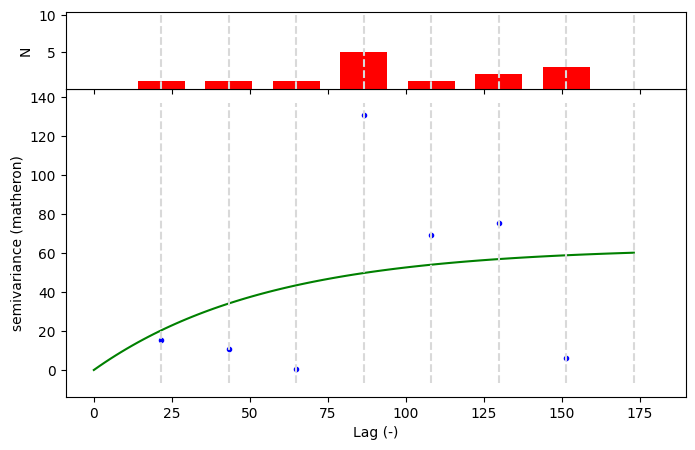

In [24]:
V1 = skg.Variogram(
    lyr1[['easting', 'northing']].values, 
    lyr1['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=8, 
    normalize=False, 
    model='exponential'
    )

fig = V1.plot()

In [25]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V1.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 166.11090288613792 meters


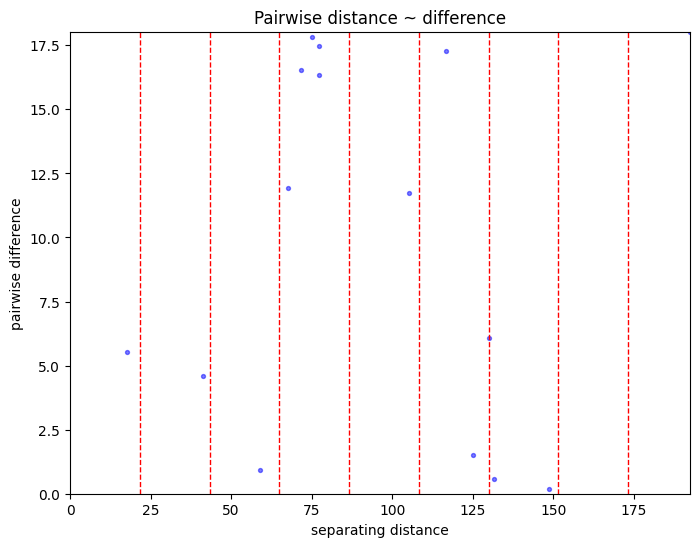

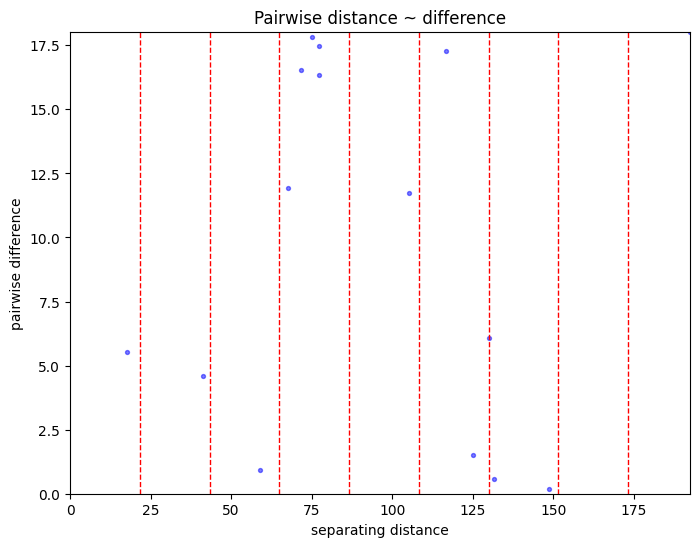

In [26]:
V1.distance_difference_plot(show=False)

In [27]:
ok1 = skg.OrdinaryKriging(V1, min_points=1, mode='exact')
x = lyr1[['easting', 'northing']].values[:, 0]
y = lyr1[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field1 = ok1.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok1.sigma.reshape(xx.shape)

In [28]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field1, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords1 = np.column_stack([df_pp1['x'].values, df_pp1['y'].values])
sampled_values1 = interpolator(sample_coords1)

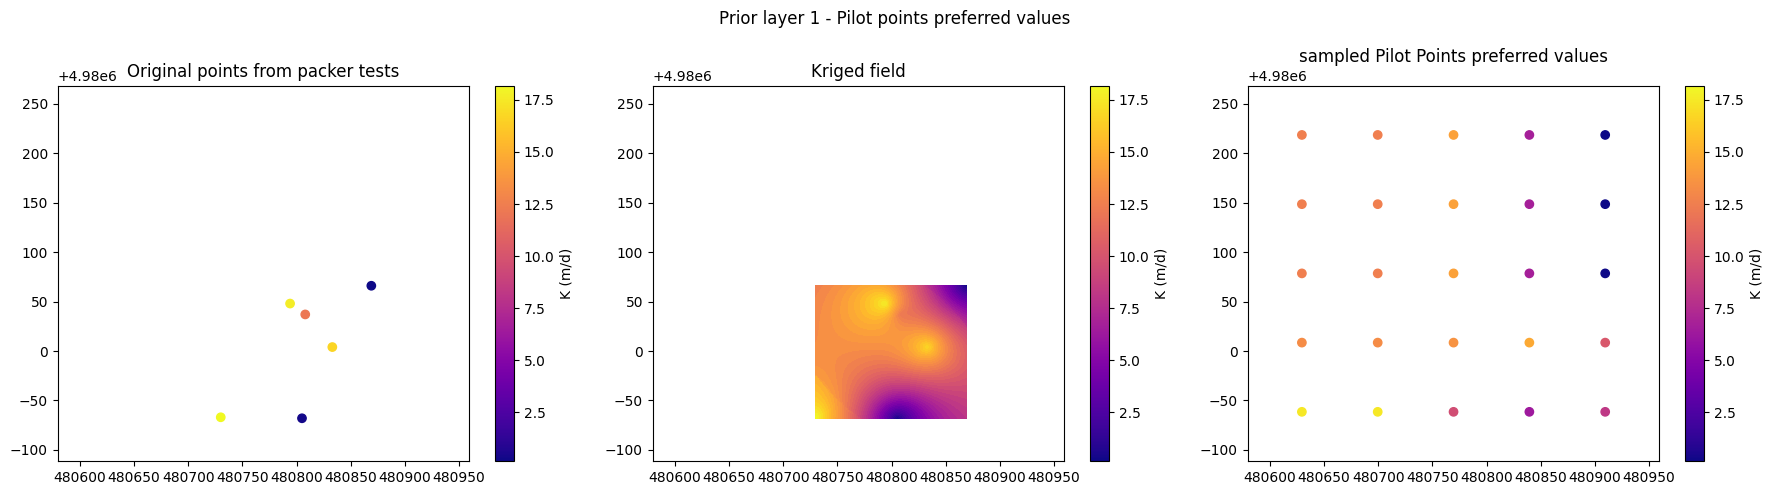

In [29]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr1['Kh (m/day)'].min(), field1.min(), sampled_values1.min())
vmax = max(lyr1['Kh (m/day)'].max(), field1.max(), sampled_values1.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr1['easting'], lyr1['northing'], 
    c=lyr1['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field1.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values1, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 1 - Pilot points preferred values')

plt.tight_layout()
plt.show()

asserting pilot point file was created

In [30]:
pp1_file = os.path.join(template_ws, "k_layer1_inst0pp.dat")
assert os.path.exists(pp1_file)

In [31]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


updating initial value + parameter bounds based on prior data uncertainty

In [32]:
df_pp1['parval1'] = 1.0
par_bnd_len1 = np.std(np.log(lyr1['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp1['parval1'].values) - (par_bnd_len1/2)
parubnd = np.log(df_pp1['parval1'].values) + (par_bnd_len1/2)
df_pp1['parlbnd'] = 10**parlbnd
df_pp1['parubnd'] = 10**parubnd

In [33]:
df_pp1.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000095,log,10576.773633,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000095,log,10576.773633,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000095,log,10576.773633,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000095,log,10576.773633,1.0,pilotpoints
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer1_inst0pp.dat,k_layer1_inst:0,1,0.0,factor,0.000095,log,10576.773633,1.0,pilotpoints


In [34]:
len(df_pp1)

25

pilot points locations

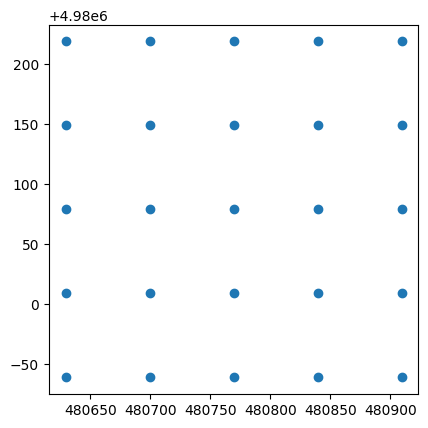

In [35]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp1.x, df_pp1.y)

adding parameter to layer 2 (BPP): constant K for now

In [36]:
df_pp2 = pf.add_parameters(
    'k_layer2.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer2", 
    #pargp="pg2", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs_2, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space='C:/Users/lima0055/Documents/MLAC-3D-HT/data/pilot-points-v1.shp', 
    )

2026-02-27 14:36:47.698323 transform was not passed, setting default transform to 'log'
2026-02-27 14:36:47.699322 starting: adding pilotpoints type m style parameters for file(s) ['k_layer2.txt']
2026-02-27 14:36:47.699322 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:30.0,anisotropy:1.0,bearing:0.0

2026-02-27 14:36:47.700322 starting: loading array template\k_layer2.txt
2026-02-27 14:36:47.756535 finished: loading array template\k_layer2.txt took: 0:00:00.056213
2026-02-27 14:36:47.756535 loaded array 'mf6\k_layer2.txt' of shape (388, 388)
2026-02-27 14:36:47.844822 starting: writing array-style template file 'template\k_layer2_inst0_pilotpoints.csv.tpl'
2026-02-27 14:36:47.844822 starting: setting up pilot point parameters
2026-02-27 14:36:47.845806 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2026-02-27 14:36:47.845806 'use_pp_zones' not set in pp_opt

In [37]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,parchglim,scale,offset,dercom
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1


In [38]:
columns_to_export = ['name', 'x', 'y', 'zone', 'parval1'] 
df_pp2_subset = df_pp2[columns_to_export]

df_pp2_subset.to_csv(
    os.path.join(template_ws, 'k_layer2_inst0pp.dat'), 
    sep=' ',          #space delimiter
    index=False,
    header=False
)

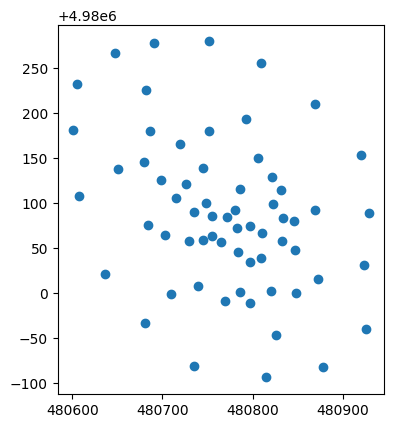

In [39]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp2.x, df_pp2.y)

importing packer + slug test data for layer 2 (BPP)

In [40]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr2 = df_packers[df_packers['layer'] == 2]
lyr2 = lyr2.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
#lyr2 = lyr2.drop(7) #dropping PZ-2, data not reliable
lyr2 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
1,PW-1,4980066,480869,2,8.500000,packer + pumping test,"packer test (PEER, 1999)",NaN,NaN
4,PW-2,4980048,480794,2,24.969600,packer test,"packer test (PEER, 1999)",NaN,NaN
7,PZ-2,4980037,480808,2,19.100000,pumping test,"pumping test (PEER, 1999)",NaN,NaN
10,94-02,4980038,480890,2,7.092215,packer test,"packer test (CNA, 1997)","average between (6.46046, 7.72397)",NaN
13,94-07,4980198,480782,2,26.408272,packer test,"packer test (CNA, 1997)","average between (18.10218, 28.69549, 38.02080, 20.81462)",NaN
16,94-08,4979864,480711,2,30.443695,packer test,"packer test (CNA, 1997)","average between (24.31918, 36.56821)",NaN
19,94-09,4979900,480919,2,23.326910,packer test,"packer test (CNA, 1997)",NaN,NaN
22,94-10,4979932,480805,2,51.195490,packer test,"packer test (CNA, 1997)",NaN,NaN
25,94-11,4980004,480833,2,16.897960,packer test,"packer test (CNA, 1997)",NaN,NaN
28,94-16,4979933,480730,2,12.193260,packer test,"packer test (CNA, 1997)",NaN,NaN


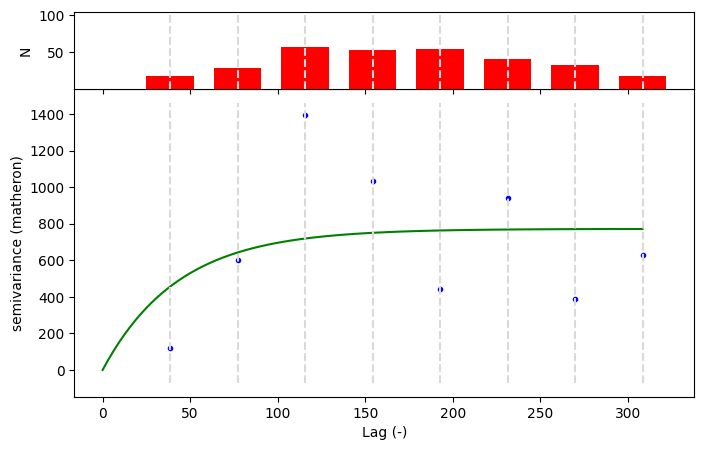

In [41]:
V2 = skg.Variogram(
    lyr2[['easting', 'northing']].values, 
    lyr2['Kh (m/day)'].values.flatten(), 
    maxlag=0.7, 
    n_lags=8, 
    normalize=False, 
    model='exponential'
    )

fig = V2.plot()

In [42]:
print(f"the correlation length based on the automatic data (poor) fitting is: {V2.describe()['effective_range']} meters")

the correlation length based on the automatic data (poor) fitting is: 129.4944223063351 meters


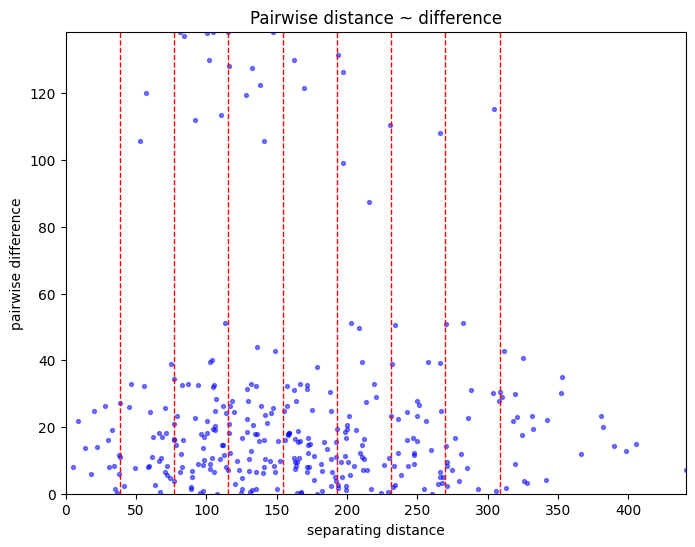

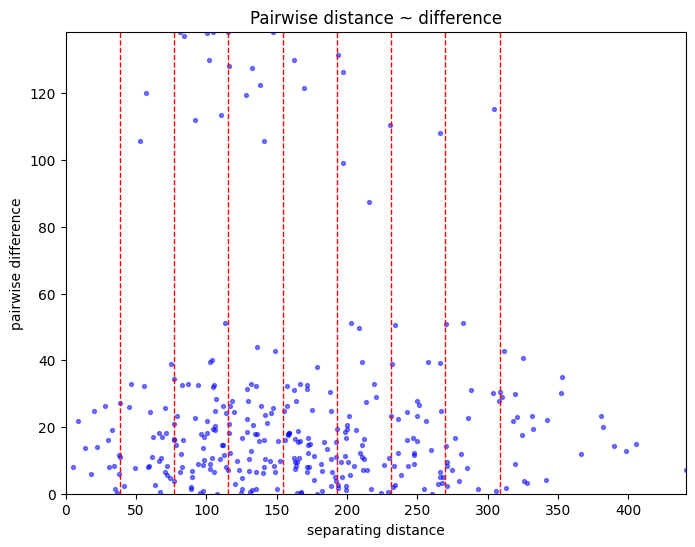

In [43]:
V2.distance_difference_plot(show=False)

In [44]:
ok2 = skg.OrdinaryKriging(V2, min_points=1, mode='exact')
x = lyr2[['easting', 'northing']].values[:, 0]
y = lyr2[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field2 = ok2.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok2.sigma.reshape(xx.shape)

In [45]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field2, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords2 = np.column_stack([df_pp2['x'].values, df_pp2['y'].values])
sampled_values2 = interpolator(sample_coords2)

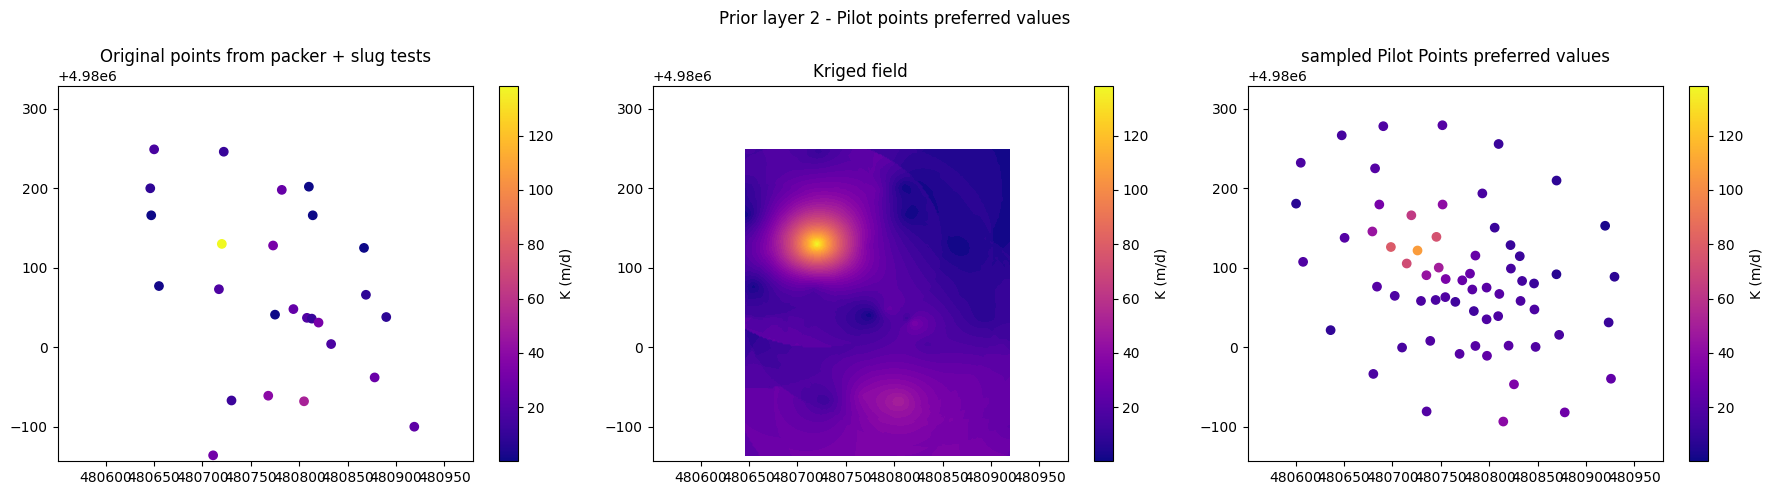

In [46]:
x_min, x_max = df_pp2['x'].min() - 50, df_pp2['x'].max() + 50
y_min, y_max = df_pp2['y'].min() - 50, df_pp2['y'].max() + 50

vmin = min(lyr2['Kh (m/day)'].min(), field2.min(), sampled_values2.min())
vmax = max(lyr2['Kh (m/day)'].max(), field2.max(), sampled_values2.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr2['easting'], lyr2['northing'], 
    c=lyr2['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer + slug tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field2.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp2['x'], df_pp2['y'], 
    #c=df_pp2['parval1'], 
    c=sampled_values2, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 2 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [47]:
pp2_file = os.path.join(template_ws, "k_layer2_inst0pp.dat")
assert os.path.exists(pp2_file)

In [48]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,parchglim,scale,offset,dercom
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,1.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,1.000000e+10,1.000000e-10,factor,1.0,0.0,1


In [49]:
df_pp2['parval1'] = 100.0
par_bnd_len2 = np.std(np.log(lyr2['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp2['parval1'].values) - (par_bnd_len2/2)
parubnd = np.log(df_pp2['parval1'].values) + (par_bnd_len2/2)
df_pp2['parlbnd'] = 10**parlbnd
df_pp2['parubnd'] = 10**parubnd
df_pp2['zone'] = 2

In [50]:
df_pp2.head()

,id,criteria,utme,utmn,name,x,y,parval1,zone,parnme,...,pp_filename,pargp,partype,partrans,parubnd,parlbnd,parchglim,scale,offset,dercom
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,1,between,480809.274,4980039.117,0,480809.273663,4.980039e+06,100.0,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480809.27_y:4980039.12_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,7.367133e+08,2.203139,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,2,between,480784.136,4980045.501,1,480784.135516,4.980046e+06,100.0,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480784.14_y:4980045.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,7.367133e+08,2.203139,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,3,between,480797.303,4980075.029,2,480797.303116,4.980075e+06,100.0,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480797.30_y:4980075.03_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,7.367133e+08,2.203139,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,4,between,480846.781,4980047.496,3,480846.781375,4.980047e+06,100.0,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480846.78_y:4980047.50_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,7.367133e+08,2.203139,factor,1.0,0.0,1
pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,5,between,480869.525,4980091.787,4,480869.525413,4.980092e+06,100.0,2,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480869.53_y:4980091.79_zone:1,...,k_layer2_inst0pp.dat,k_layer2_inst:0,pilotpoints,log,7.367133e+08,2.203139,factor,1.0,0.0,1


In [51]:
len(df_pp2)

64

Adding parameter to layer 3: pilot points

In [52]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
#ib3 = gwf.dis.idomain.array[2]
#plt.imshow(ib3)

In [53]:
df_pp3 = pf.add_parameters(
    'k_layer3.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer3", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells

    geostruct=pp_gs, #geostructure of the pilot points #for interpolate from pp to model grid 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    #lower_bound=0.01, upper_bound=1000, 
    #ult_ubound=1000, ult_lbound=0.001,
    pp_space=70
)

2026-02-27 14:37:13.648885 transform was not passed, setting default transform to 'log'
2026-02-27 14:37:13.649884 starting: adding pilotpoints type m style parameters for file(s) ['k_layer3.txt']
2026-02-27 14:37:13.649884 finished: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:150.0,anisotropy:1.0,bearing:0.0
 took: 0:00:51.423500
2026-02-27 14:37:13.649884 starting: loading array template\k_layer3.txt
2026-02-27 14:37:13.689670 finished: loading array template\k_layer3.txt took: 0:00:00.039786
2026-02-27 14:37:13.689670 loaded array 'mf6\k_layer3.txt' of shape (388, 388)
2026-02-27 14:37:13.812331 starting: writing array-style template file 'template\k_layer3_inst0_pilotpoints.csv.tpl'
2026-02-27 14:37:13.812331 starting: setting up pilot point parameters
2026-02-27 14:37:13.813339 WARNING: Directly passing 'pp_space' has been deprecated and will eventually be removed, please use pp_options['pp_space'] instead.
2026-02-27 14:37:13.813339 'use_pp_zo

In [54]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,1.000000e-10,log,1.000000e+10,1.0,pilotpoints


Importing packer test data for layer 3

In [55]:
df_packers = pd.read_excel('../../../data/MODFLOW_layers_priors.xlsx')
lyr3 = df_packers[df_packers['layer'] == 3]
lyr3 = lyr3.dropna(subset=['easting', 'northing', 'Kh (m/day)']) #dropping nans
lyr3 = lyr3.drop(8) #dropping PZ-2, data not reliable
lyr3 #packer data for layer 1

,borehole,northing,easting,layer,Kh (m/day),method,source,notes,old value
2,PW-1,4980066,480869,3,0.042080,packer test,"packer test (PEER, 1999)",NaN,NaN
11,94-02,4980038,480890,3,0.209863,packer test,"packer test (CNA, 1997)","average between (0.37042, 0.17790, 0.15445, 0.13668)",NaN
14,94-07,4980198,480782,3,0.237867,packer test,"packer test (CNA, 1997)","average between (0.27337, 0.23365, 0.20658)",NaN
17,94-08,4979864,480711,3,0.288900,packer test,"packer test (CNA, 1997)","average between (0.30866, 0.42640, 0.13164)",NaN
20,94-09,4979900,480919,3,3.274515,packer test,"packer test (CNA, 1997)","average between (12.30757, 0.22225, 0.19762, 0.37062)",NaN
23,94-10,4979932,480805,3,0.149703,packer test,"packer test (CNA, 1997)","average between (0.16944, 0.14803, 0.13164)",NaN
26,94-11,4980004,480833,3,0.879843,packer test,"packer test (CNA, 1997)","average between (0.07402, 1.01561, 1.54990)",NaN
29,94-16,4979933,480730,3,0.458860,packer test,"packer test (CNA, 1997)","average between (1.51673, 0.11113, 0.10162, 0.10596)",NaN


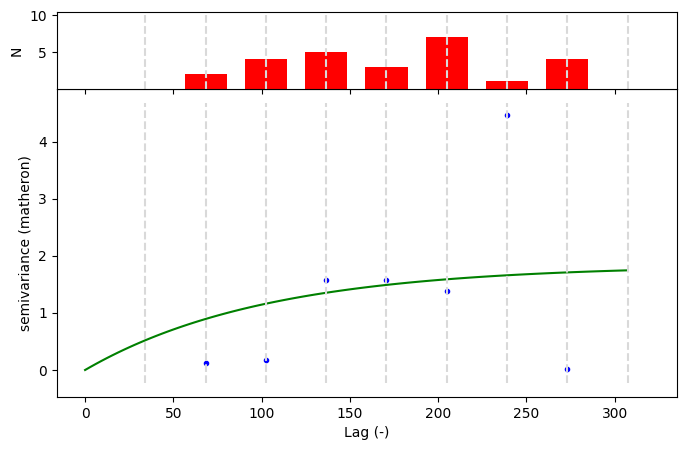

In [56]:
V3 = skg.Variogram(
    lyr3[['easting', 'northing']].values, 
    lyr3['Kh (m/day)'].values.flatten(), 
    maxlag=0.9, 
    n_lags=9, 
    normalize=False, 
    model='exponential'
    )

fig = V3.plot()

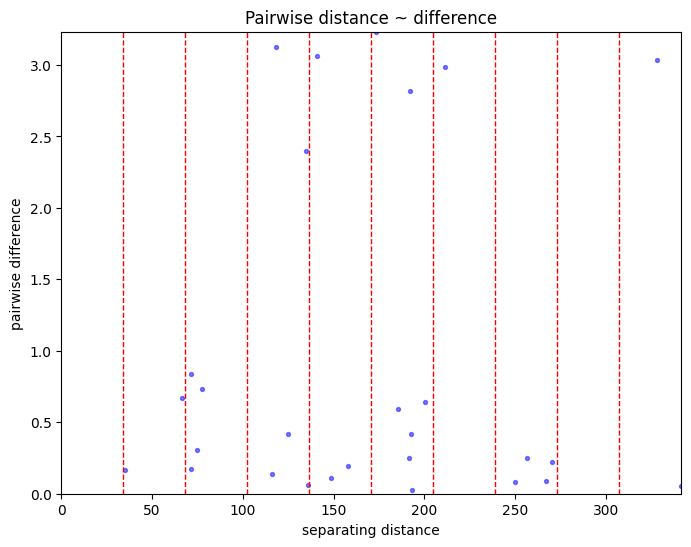

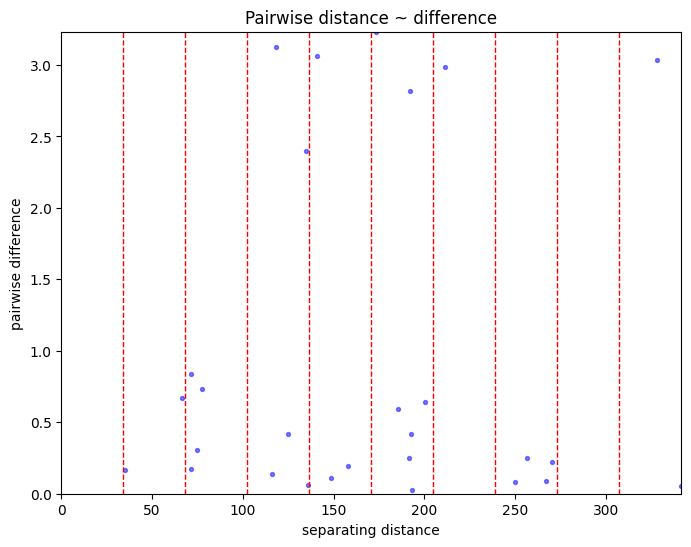

In [57]:
V3.distance_difference_plot(show=False)

In [58]:
print(f"the correlation length for layer 3 based on the packer test data is: {V3.describe()['effective_range']}")

the correlation length for layer 3 based on the packer test data is: 307.31672587088383


In [59]:
ok3 = skg.OrdinaryKriging(V3, min_points=1, mode='exact')
x = lyr3[['easting', 'northing']].values[:, 0]
y = lyr3[['easting', 'northing']].values[:, 1]
xx, yy = np.mgrid[x.min():x.max():200j, y.min():y.max():200j]
field3 = ok3.transform(xx.flatten(), yy.flatten()).reshape(xx.shape)
s2 = ok3.sigma.reshape(xx.shape)

In [60]:
interpolator = RegularGridInterpolator(
    (xx[:, 0], yy[0, :]), 
    field3, 
    method='nearest', 
    bounds_error=False, 
    #fill_value=10.848392, 
    fill_value=None, 
    )
sample_coords3 = np.column_stack([df_pp3['x'].values, df_pp3['y'].values])
sampled_values3 = interpolator(sample_coords3)

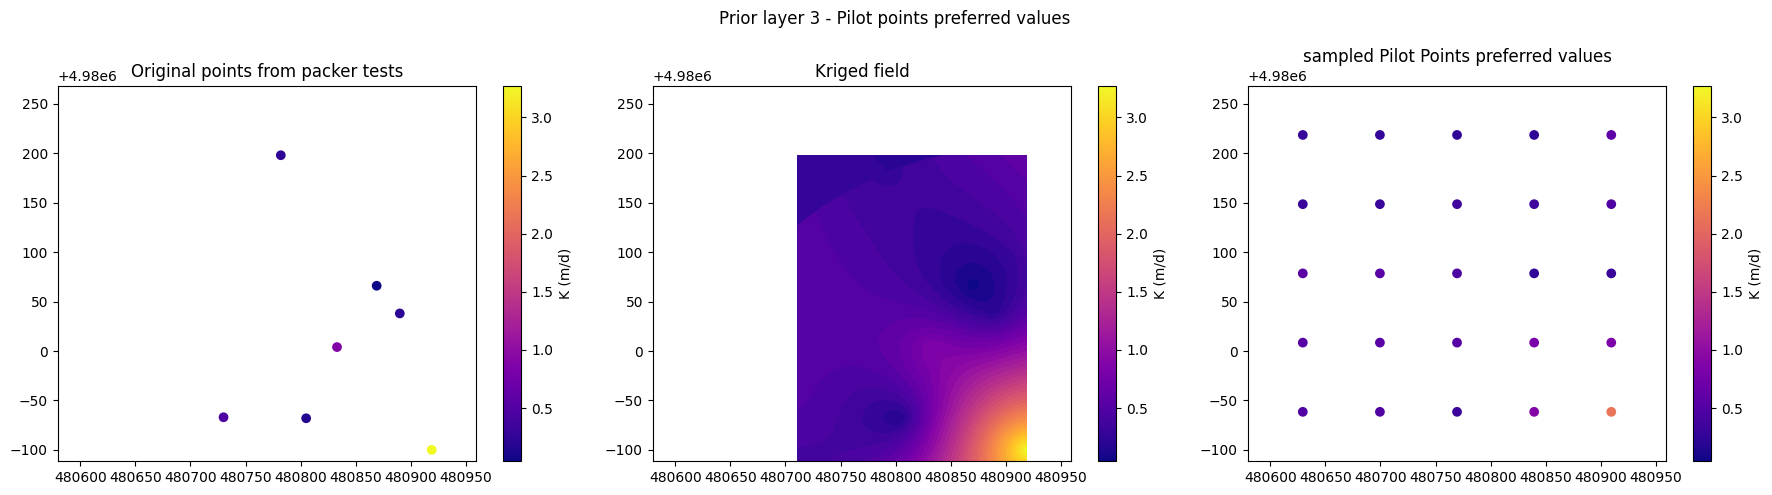

In [61]:
x_min, x_max = df_pp1['x'].min() - 50, df_pp1['x'].max() + 50
y_min, y_max = df_pp1['y'].min() - 50, df_pp1['y'].max() + 50

vmin = min(lyr3['Kh (m/day)'].min(), field3.min(), sampled_values3.min())
vmax = max(lyr3['Kh (m/day)'].max(), field3.max(), sampled_values3.max())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#original data packer test
sc1 = ax1.scatter(
    lyr3['easting'], lyr3['northing'], 
    c=lyr3['Kh (m/day)'], 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax1.set_title('Original points from packer tests')
plt.colorbar(sc1, ax=ax1, label='K (m/d)')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

#kriged field
sc2 = ax2.contourf(
    np.linspace(x.min(),x.max(),200), 
    np.linspace(y.min(),y.max(),200), 
    field3.T, 
    origin='lower', cmap='plasma', 
    vmin=vmin, vmax=vmax, 
    levels=50
    )
ax2.set_title('Kriged field')
plt.colorbar(sc1, ax=ax2, label='K (m/d)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

sc3 = ax3.scatter(
    df_pp1['x'], df_pp1['y'], 
    #c=df_pp1['parval1'], 
    c=sampled_values3, 
    cmap='plasma', 
    vmin=vmin, vmax=vmax,
    )
ax3.set_title('sampled Pilot Points preferred values')
plt.colorbar(sc3, ax=ax3, label='K (m/d)')
ax3.set_xlim(x_min, x_max)
ax3.set_ylim(y_min, y_max)

# Plot interpolated points
fig.suptitle('Prior layer 3 - Pilot points preferred values')

plt.tight_layout()
plt.show()

In [62]:
pp3_file = os.path.join(template_ws, "k_layer3_inst0pp.dat")
assert os.path.exists(pp3_file)

updating layer index, initial value, and pilot points parameter bounds

In [63]:
df_pp3['k'] = 2
df_pp3['parval1'] = 0.01
par_bnd_len3 = np.std(np.log(lyr3['Kh (m/day)'].values))*4
parlbnd = np.log(df_pp3['parval1'].values) - (par_bnd_len3/2)
parubnd = np.log(df_pp3['parval1'].values) + (par_bnd_len3/2)
df_pp3['parlbnd'] = 10**parlbnd
df_pp3['parubnd'] = 10**parubnd
df_pp3['zone'] = 3

In [64]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,...,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale,partype
parnme,,,,,,,,,,,,,,,,,,,,,
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pp_0000,480629.50046,4.980219e+06,3,0.01,2,35,35,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,9.858801e-08,log,0.006249,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pp_0001,480699.50046,4.980219e+06,3,0.01,2,35,105,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,9.858801e-08,log,0.006249,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pp_0002,480769.50046,4.980219e+06,3,0.01,2,35,175,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,9.858801e-08,log,0.006249,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pp_0003,480839.50046,4.980219e+06,3,0.01,2,35,245,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,9.858801e-08,log,0.006249,1.0,pilotpoints
pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pp_0004,480909.50046,4.980219e+06,3,0.01,2,35,315,pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,~ pname:k_layer3_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1 ~,...,template\k_layer3_inst0pp.dat,k_layer3_inst:0,1,0.0,factor,9.858801e-08,log,0.006249,1.0,pilotpoints


Adding specific storage as a fitting parameter (constant ss for each layer)

In [65]:
'''df_ss1 = pf.add_parameters(
    "ss_layer1.txt", 
    par_type='constant', 
    par_name_base="ss_layer1", 
    pargp="ss_layer1", 
    initial_value=1e-5, 
    lower_bound=1e-6, ult_lbound=1e-6, 
    upper_bound=1, ult_ubound=1
)'''

'df_ss1 = pf.add_parameters(\n    "ss_layer1.txt", \n    par_type=\'constant\', \n    par_name_base="ss_layer1", \n    pargp="ss_layer1", \n    initial_value=1e-5, \n    lower_bound=1e-6, ult_lbound=1e-6, \n    upper_bound=1, ult_ubound=1\n)'

In [66]:
'''df_ss2 = pf.add_parameters(
    "ss_layer2.txt", 
    par_type='constant', 
    par_name_base="ss_layer2", 
    pargp="ss_layer2", 
    initial_value=1e-5, 
    lower_bound=1e-6, ult_lbound=1e-6, 
    upper_bound=1, ult_ubound=1
)'''

'df_ss2 = pf.add_parameters(\n    "ss_layer2.txt", \n    par_type=\'constant\', \n    par_name_base="ss_layer2", \n    pargp="ss_layer2", \n    initial_value=1e-5, \n    lower_bound=1e-6, ult_lbound=1e-6, \n    upper_bound=1, ult_ubound=1\n)'

In [67]:
'''df_ss3 = pf.add_parameters(
    "ss_layer3.txt", 
    par_type='constant', 
    par_name_base="ss_layer3", 
    pargp="ss_layer3", 
    initial_value=1e-5, 
    lower_bound=1e-6, ult_lbound=1e-6, 
    upper_bound=1, ult_ubound=1
)'''

'df_ss3 = pf.add_parameters(\n    "ss_layer3.txt", \n    par_type=\'constant\', \n    par_name_base="ss_layer3", \n    pargp="ss_layer3", \n    initial_value=1e-5, \n    lower_bound=1e-6, ult_lbound=1e-6, \n    upper_bound=1, ult_ubound=1\n)'

Adding mf6 to the command script

In [68]:
pf.mod_sys_cmds.append("mf6") #do this only once
pf.mod_sys_cmds

['mf6']

adding the processing MODFLOW output in the PEST running script. 

This processing script reads the MODFLOW simulation output (heads for all well in all simulation time steps), and sample heads only for desired times (i.e. times that we have field data) using interpolation, then overwrites the heads.csv (MODFLOW output) used to compared with the observation data added to the PEST control file.

In [69]:
pf.add_py_function("helpers.py","process_heads_csv()",is_pre_cmd=False)

building pst

In [70]:
pst = pf.build_pst()

2026-02-27 14:37:26.325312 starting: Converting parameters to shortnames
2026-02-27 14:37:26.330319 starting: Renaming parameters for shortnames
2026-02-27 14:37:30.937834 finished: Renaming parameters for shortnames took: 0:00:04.607515
2026-02-27 14:37:30.962846 finished: Converting parameters to shortnames took: 0:00:04.637534
2026-02-27 14:37:30.965040 starting: Converting observations to shortnames
2026-02-27 14:37:30.969195 starting: Renaming observations for shortnames
2026-02-27 14:37:36.020928 finished: Renaming observations for shortnames took: 0:00:05.051733
2026-02-27 14:37:36.050525 finished: Converting observations to shortnames took: 0:00:05.085485
noptmax:0, npar_adj:114, nnz_obs:120
2026-02-27 14:37:36.116888 forward_run line:pyemu.os_utils.run(r'mf6')



Changing observation groups based on layers

In [71]:
condition1 = pst.observation_data['longname'].str.contains('pw2-1|pz1-1', case=False, regex=True)
condition3 = pst.observation_data['longname'].str.contains('pz1-3', case=False, regex=True)
condition2 = [not element for element in condition1.values + condition3.values]
pst.observation_data.loc[condition1, 'obgnme'] = 'ob0'
pst.observation_data.loc[condition2, 'obgnme'] = 'ob1'
pst.observation_data.loc[condition3, 'obgnme'] = 'ob2'

In [72]:
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,longname,shortname,oglong,oname,otype,time,usecol
ob0,ob0,0.010999,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,ob0,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.010417,head
ob1,ob1,0.022082,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.020833,head
ob2,ob2,0.037808,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,ob2,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.041667,head
ob3,ob3,0.049898,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,ob3,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow17p,pmw-3,lst,0.0625,head
ob4,ob4,0.006916,1.0,ob1,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,ob4,oname:pmw-3_heads.csv_otype:lst_usecol:head_ow23p,pmw-3,lst,0.010417,head


Changing forward_run.py file to move to each simulation folder and run MODFLOW in there, 

This is, for now, MODFLOW is running sequentially

In [73]:
filename = os.path.join(template_ws, 'forward_run.py')
search_code = "    pyemu.os_utils.run(r'mf6')\n"

paths = [os.path.basename(os.path.normpath(p)) for p in path]

new_code = ''
for i in paths: 
    new_code = new_code + f"    os.chdir('{i}') \n    pyemu.os_utils.run(r'mf6') #running MODFLOW in {i} \n    os.chdir('..')\n"

In [74]:
from helpers import replace_forward_run

replace_forward_run(filename, search_code, new_code)

checking parameter groups and data

In [75]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


In [76]:
pst.parameter_data.sample(5)

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,x,y,zone
p56,p56,log,factor,100.0,2.203139,7.367133e+08,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480785.73_y:4980115.33_zone:1,p56,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480785.73,4980115.33,1
p86,p86,log,factor,100.0,2.203139,7.367133e+08,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480814.56_y:4979906.51_zone:1,p86,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480814.56,4979906.51,1
p1,p1,log,factor,1.0,0.000095,1.057677e+04,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,p1,k_layer1_inst:0,35,0,105,k,m,pp,NaN,NaN,1
p53,p53,log,factor,100.0,2.203139,7.367133e+08,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480714.71_y:4980105.35_zone:1,p53,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480714.71,4980105.35,1
p84,p84,log,factor,100.0,2.203139,7.367133e+08,pg1,1.0,0.0,1,pname:k_layer2_inst:0_ptype:pp_pstyle:m_x:480680.20_y:4979966.42_zone:1,p84,k_layer2_inst:0,NaN,0,NaN,k,m,pp,480680.20,4979966.42,1


## checking phimlim for investigation of minimum phi

In [77]:
pst.reg_data.phimlim

'1.0e-10'

minimum phi should be equal to the number of non-zero weighted observations

THIS ASSUMES THAT ALL MODEL-TO-MEASUREMENT MISFIT IS DUE TO MEASUREMENT UNCERTAINTY. In practice model error usually plays a larger role

In [78]:
pst.nnz_obs

120

aasigning PHILIM equal to the number of non-zero weighted observations

In [79]:
#pst.reg_data.phimlim = pst.nnz_obs
pst.reg_data.phimlim

'1.0e-10'

When changing PHIMLIM, we must also change PHIMACCEPT. this is the level of acceptable "measurement objective function".

If PEST achieves PHIMLIM, it will then attempt to minimize the regularization objective function, whiilst maintaining the measurement objective function below PHIMACCEPT

In [80]:
#setting PHIMACCEPT 10% higher than PHIMLIM
pst.reg_data.phimaccept = float(pst.reg_data.phimlim) * 1.1
pst.reg_data.phimaccept

1.1000000000000001e-10

changing PESTMODE to regularization

In [81]:
pst.control_data.pestmode = 'regularization'
pst.control_data.pestmode

'regularization'

In [82]:
pst.control_data.rlambda1

20.0

In [83]:
pst.control_data.rlambda1 = 1.0
#pst.control_data.rlambda1

updating the maximum number of PEST iteration

In [84]:
pst.control_data.noptmax = 0
pst.control_data.noptmax

np.int32(0)

In [85]:
print(f'there are {pst.nobs} field observation')

there are 120 field observation


Checking input and output model files

In [86]:
pst.model_input_data

,pest_file,model_file
k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat
k_layer2_inst0pp.dat.tpl,k_layer2_inst0pp.dat.tpl,k_layer2_inst0pp.dat
k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat


In [87]:
pst.model_output_data

,pest_file,model_file
PMW-3_heads.csv.ins,PMW-3_heads.csv.ins,PMW-3_heads.csv
PMW-6_heads.csv.ins,PMW-6_heads.csv.ins,PMW-6_heads.csv


Adding priors

In [88]:
pst.prior_information #no prior info up to now

,pilbl,obgnme,equation,weight


In [89]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
pg1,pg1,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg0,pg0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
pg2,pg2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


adding preferred-value equations

In [90]:
#applying preferred value regularization on all parameters
pyemu.helpers.zero_order_tikhonov(
    pst, parbounds=True, #using parameter bounds to specify prior information equation weights
    par_groups=['pg0', 'pg1', 'pg2'], #adding preferred-value only for pp in layer 1 and 3
    ) #setting up preferred-value regularization in the pest control file


In [91]:
pst.prior_information.head()

,pilbl,equation,obgnme,weight
pilbl,,,,
p0,p0,1.0 * log(p0) = 0.000000E+00,regulpg0,0.124244
p1,p1,1.0 * log(p1) = 0.000000E+00,regulpg0,0.124244
p2,p2,1.0 * log(p2) = 0.000000E+00,regulpg0,0.124244
p3,p3,1.0 * log(p3) = 0.000000E+00,regulpg0,0.124244
p4,p4,1.0 * log(p4) = 0.000000E+00,regulpg0,0.124244


In [92]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,p0,k_layer1_inst:0,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,p1,k_layer1_inst:0,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,p2,k_layer1_inst:0,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,p3,k_layer1_inst:0,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,p4,k_layer1_inst:0,35,0,315,k,m,pp,NaN,NaN,1


In [93]:
def calculate_weights_priors(pst, layer_dfs, slugtest_dfs, min_weight=0.1, max_weight=3.0, influence_range=50.0, p=2.0, log_transform=True): 
    n_layers = len(layer_dfs)
    results = {}

    for layer_idx in range(n_layers): 
        pp_df = layer_dfs[layer_idx].copy()
        slug_df = slugtest_dfs[layer_idx].copy()

        #extract array
        pp_coords = pp_df[['x', 'y']].values
        #pp_names = pp_df['parnme'].values
        #pp_initial_K = pp_df['parval1'].values
        
        slug_coords = slug_df[['easting', 'northing']].values
        #slug_K = slug_df['k_value'].values
        
        # Convert to log10 if requested
        '''if log_transform:
            if np.any(pp_initial_K <= 0):
                print(f"Warning: Non-positive K values in layer {layer_idx+1}. Adding small offset.")
                offset = np.abs(np.min(pp_initial_K)) + 1e-10
                pp_initial_K = pp_initial_K + offset
            pp_initial_K = np.log10(pp_initial_K)
            slug_K = np.log10(slug_K)'''
        
        n_pps = len(pp_coords)
        n_wells = len(slug_coords)
        
        # Calculate distances from each pilot point to each slug test
        distances = np.zeros((n_pps, n_wells))
        for i in range(n_pps):
            for j in range(n_wells):
                dx = pp_coords[i, 0] - slug_coords[j, 0]
                dy = pp_coords[i, 1] - slug_coords[j, 1]
                distances[i, j] = np.sqrt(dx**2 + dy**2)
        
        # Find minimum distance to any well for each pilot point
        min_distances = np.min(distances, axis=1)
        closest_well_idx = np.argmin(distances, axis=1)
        
        # Calculate weights using exponential decay
        weights = np.zeros(n_pps)
        #preferred_K = np.zeros(n_pps)
        
        for i in range(n_pps):
            d = min_distances[i]
            closest_idx = closest_well_idx[i]
            
            # Exponential decay weight calculation
            # weight = min + (max-min) * [1 - exp(-(d/range)^p)]
            normalized_distance = (d / influence_range) ** p
            decay_factor = 1.0 - np.exp(-normalized_distance)
            weights[i] = min_weight + (max_weight - min_weight) * decay_factor
            
            # Preferred K: blend of slug test values using inverse distance weighting
            # Calculate weights for interpolation
            '''inv_dist_weights = 1.0 / (distances[i, :] + 1e-10)  # Add small to avoid division by zero
            inv_dist_weights = inv_dist_weights / np.sum(inv_dist_weights)
            
            if log_transform:
                # Interpolate in log space
                preferred_logK = np.sum(slug_K * inv_dist_weights)
                preferred_K[i] = 10 ** preferred_logK  # Convert back to linear for display
                preferred_K_log = preferred_logK  # Keep for PEST
            else:
                # Interpolate in linear space
                preferred_K[i] = np.sum(slug_K * inv_dist_weights)
                preferred_K_log = preferred_K[i]'''
            
            # Store the preferred value in log space for PEST
            #pp_df.loc[pp_df.index[i], 'preferred_logK'] = preferred_K_log
            pp_df.loc[pp_df.index[i], 'preferred_weight'] = weights[i]
            pp_df.loc[pp_df.index[i], 'min_distance'] = d
        
        # Calculate confidence (inverse of regularization weight)
        confidence = 1.0 / weights
        
        # Store results for this layer
        results[f'layer_{layer_idx+1}'] = {
            'pilot_points': pp_df,
            'weights': weights,
            #'preferred_K': preferred_K,
            'min_distances': min_distances,
            'confidence': confidence,
            'slug_test_locations': slug_df
        }
        
        # Print summary for this layer
        print(f"Number of pilot points: {n_pps}")
        print(f"Number of slug tests: {n_wells}")
        print(f"Weight statistics: min={weights.min():.3f}, max={weights.max():.3f}, mean={weights.mean():.3f}")
        print(f"Average distance to nearest slug test: {min_distances.mean():.1f} m")
    
    return results, pst

In [94]:
pp_df_list = [df_pp1, df_pp2, df_pp3]
slug_df_list = [lyr1, lyr2, lyr3]

results, pst = calculate_weights_priors(pst, pp_df_list, slug_df_list)

Number of pilot points: 25
Number of slug tests: 6
Weight statistics: min=0.172, max=3.000, mean=2.381
Average distance to nearest slug test: 101.9 m
Number of pilot points: 64
Number of slug tests: 26
Weight statistics: min=0.107, max=2.582, mean=1.186
Average distance to nearest slug test: 34.0 m
Number of pilot points: 25
Number of slug tests: 8
Weight statistics: min=0.172, max=3.000, mean=2.182
Average distance to nearest slug test: 79.2 m


In [95]:
def visualize_distance_weights(results_dict, layer_idx=0):
    """
    Visualize the distance-weight relationship for a specific layer.
    
    Parameters
    ----------
    results_dict : dict
        Dictionary returned by calculate_distance_weighted_priors
    layer_idx : int, default=0
        Layer index to visualize (0-based)
    """
    
    import matplotlib.pyplot as plt
    
    layer_key = f'layer_{layer_idx+1}'
    if layer_key not in results_dict:
        print(f"Layer {layer_key} not found in results")
        return
    
    layer_data = results_dict[layer_key]
    pp_df = layer_data['pilot_points']
    slug_df = layer_data['slug_test_locations']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Distance-Weighted Priors - Layer {layer_idx+1}', fontsize=16)
    
    # Plot 1: Pilot points with weights
    sc1 = axes[0, 0].scatter(pp_df['x'], pp_df['y'], 
                            c=pp_df['preferred_weight'],
                            cmap='viridis_r', s=100, edgecolor='k')
    axes[0, 0].scatter(slug_df['easting'], slug_df['northing'],
                      c='red', s=200, marker='^', label='Slug Tests')
    axes[0, 0].set_title('Regularization Weight\n(Lower = Stronger Constraint)')
    axes[0, 0].set_xlabel('X (m)'); axes[0, 0].set_ylabel('Y (m)')
    plt.colorbar(sc1, ax=axes[0, 0])
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Confidence (inverse weight)
    confidence = 1.0 / pp_df['preferred_weight']
    sc2 = axes[0, 1].scatter(pp_df['x'], pp_df['y'],
                            c=confidence,
                            cmap='plasma', s=100, edgecolor='k')
    axes[0, 1].scatter(slug_df['easting'], slug_df['northing'],
                      c='red', s=200, marker='^')
    axes[0, 1].set_title('Confidence in Prior\n(Higher = More Confident)')
    axes[0, 1].set_xlabel('X (m)'); axes[0, 1].set_ylabel('Y (m)')
    plt.colorbar(sc2, ax=axes[0, 1])
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Distance vs Weight
    axes[1, 0].scatter(pp_df['min_distance'], pp_df['preferred_weight'], s=50)
    axes[1, 0].set_xlabel('Distance to Nearest Slug Test (m)')
    axes[1, 0].set_ylabel('Regularization Weight')
    axes[1, 0].set_title('Weight vs Distance')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot theoretical decay curve
    distances = np.linspace(0, pp_df['min_distance'].max(), 100)
    min_weight = pp_df['preferred_weight'].min()
    max_weight = pp_df['preferred_weight'].max()
    influence_range = 50.0  # Default, adjust if different
    theoretical_weights = min_weight + (max_weight - min_weight) * (1 - np.exp(-(distances/influence_range)**2))
    axes[1, 0].plot(distances, theoretical_weights, 'r-', label='Exponential Decay')
    axes[1, 0].legend()
    
    # Plot 4: Histogram of weights
    axes[1, 1].hist(pp_df['preferred_weight'], bins=20,
                   edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Regularization Weight')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Weights')
    axes[1, 1].grid(True, alpha=0.3)
    
    '''# Plot 5: Initial vs Preferred K
    if 'preferred_K' in pp_df.columns:
        axes[1, 1].scatter(pp_df['parval1'], pp_df['preferred_K'], s=50)
        # Add 1:1 line
        min_val = min(pp_df['parval1'].min(), pp_df['preferred_K'].min())
        max_val = max(pp_df['parval1'].max(), pp_df['preferred_K'].max())
        axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
        axes[1, 1].set_xlabel('Initial K (from model)')
        axes[1, 1].set_ylabel('Preferred K (from slug tests)')
        axes[1, 1].set_title('K Adjustment')
        axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Spatial distribution of preferred K
    sc6 = axes[1, 2].scatter(pp_df['x'], pp_df['y'],
                            c=pp_df['preferred_K'],
                            cmap='YlOrRd', s=100, edgecolor='k', norm='log')
    axes[1, 2].scatter(slug_df['x'], slug_df['y'],
                      c='blue', s=200, marker='^', label='Slug Tests')
    axes[1, 2].set_title('Preferred K Values (m/s)')
    axes[1, 2].set_xlabel('X (m)'); axes[1, 2].set_ylabel('Y (m)')
    plt.colorbar(sc6, ax=axes[1, 2])
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)'''
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print(f"\nLayer {layer_idx+1} - Weight Statistics:")
    print("=" * 50)
    print(f"{'Distance Range (m)':<20} {'Weight Range':<20} {'Count':<10}")
    print("-" * 50)
    
    bins = [0, 10, 20, 30, 50, 100, np.inf]
    for i in range(len(bins)-1):
        mask = (pp_df['min_distance'] >= bins[i]) & (pp_df['min_distance'] < bins[i+1])
        if mask.any():
            subset = pp_df.loc[mask, 'preferred_weight']
            print(f"{bins[i]:3.0f} - {bins[i+1]:3.0f}      "
                  f"{subset.min():5.3f} - {subset.max():5.3f}      "
                  f"{mask.sum():<10}")

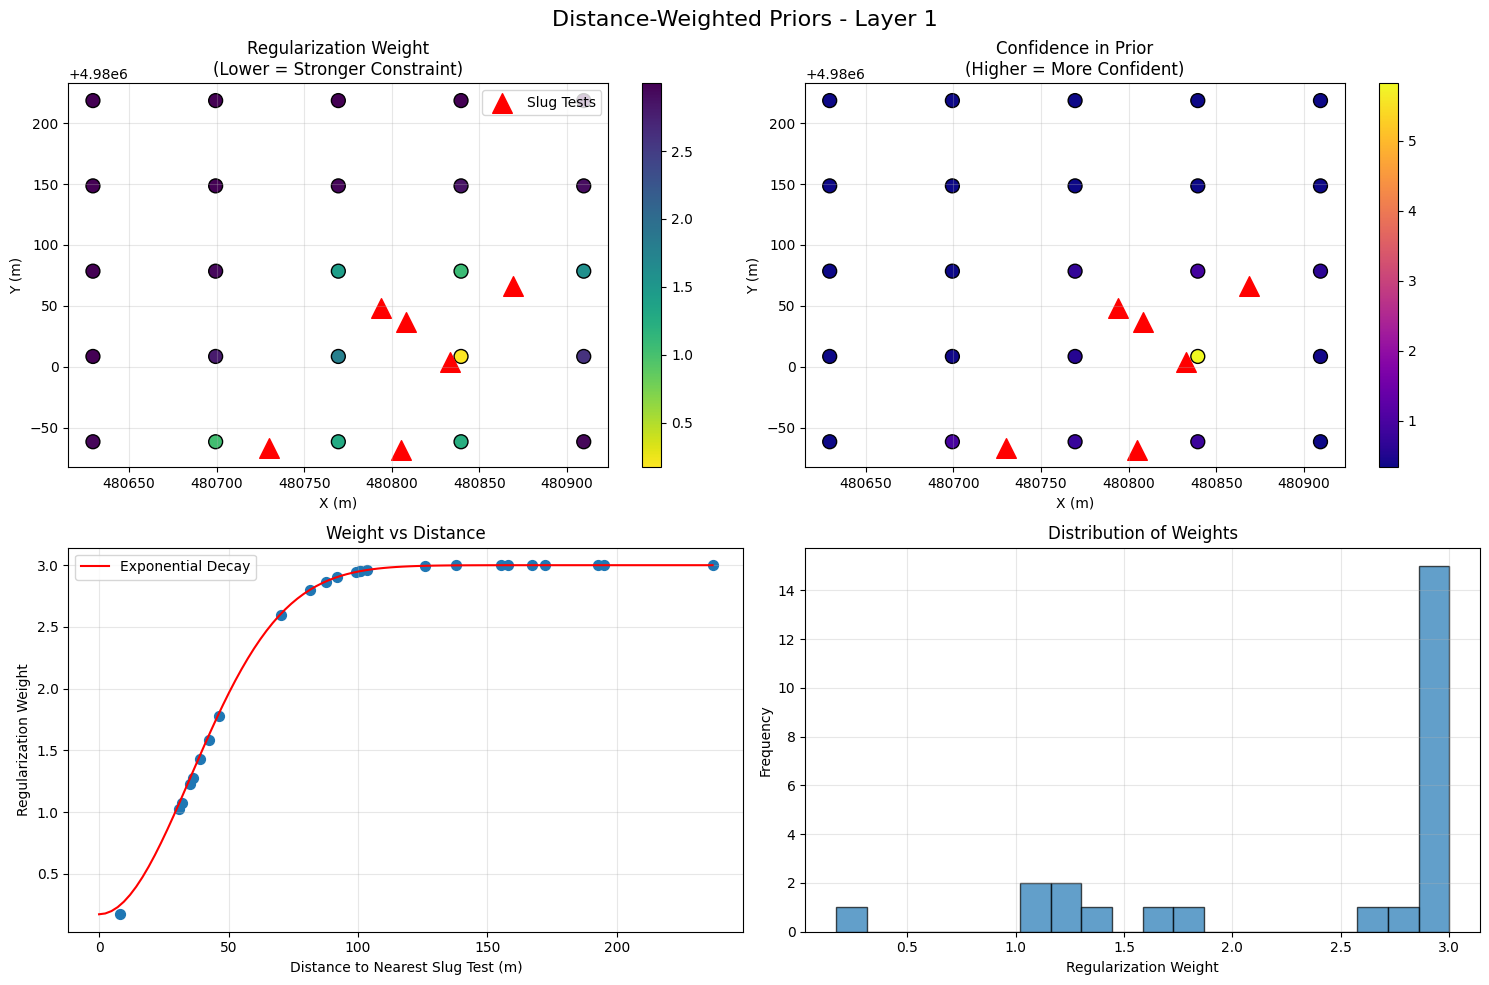


Layer 1 - Weight Statistics:
Distance Range (m)   Weight Range         Count     
--------------------------------------------------
  0 -  10      0.172 - 0.172      1         
 30 -  50      1.025 - 1.778      7         
 50 - 100      2.599 - 2.944      5         
100 - inf      2.950 - 3.000      12        


In [96]:
visualize_distance_weights(results)

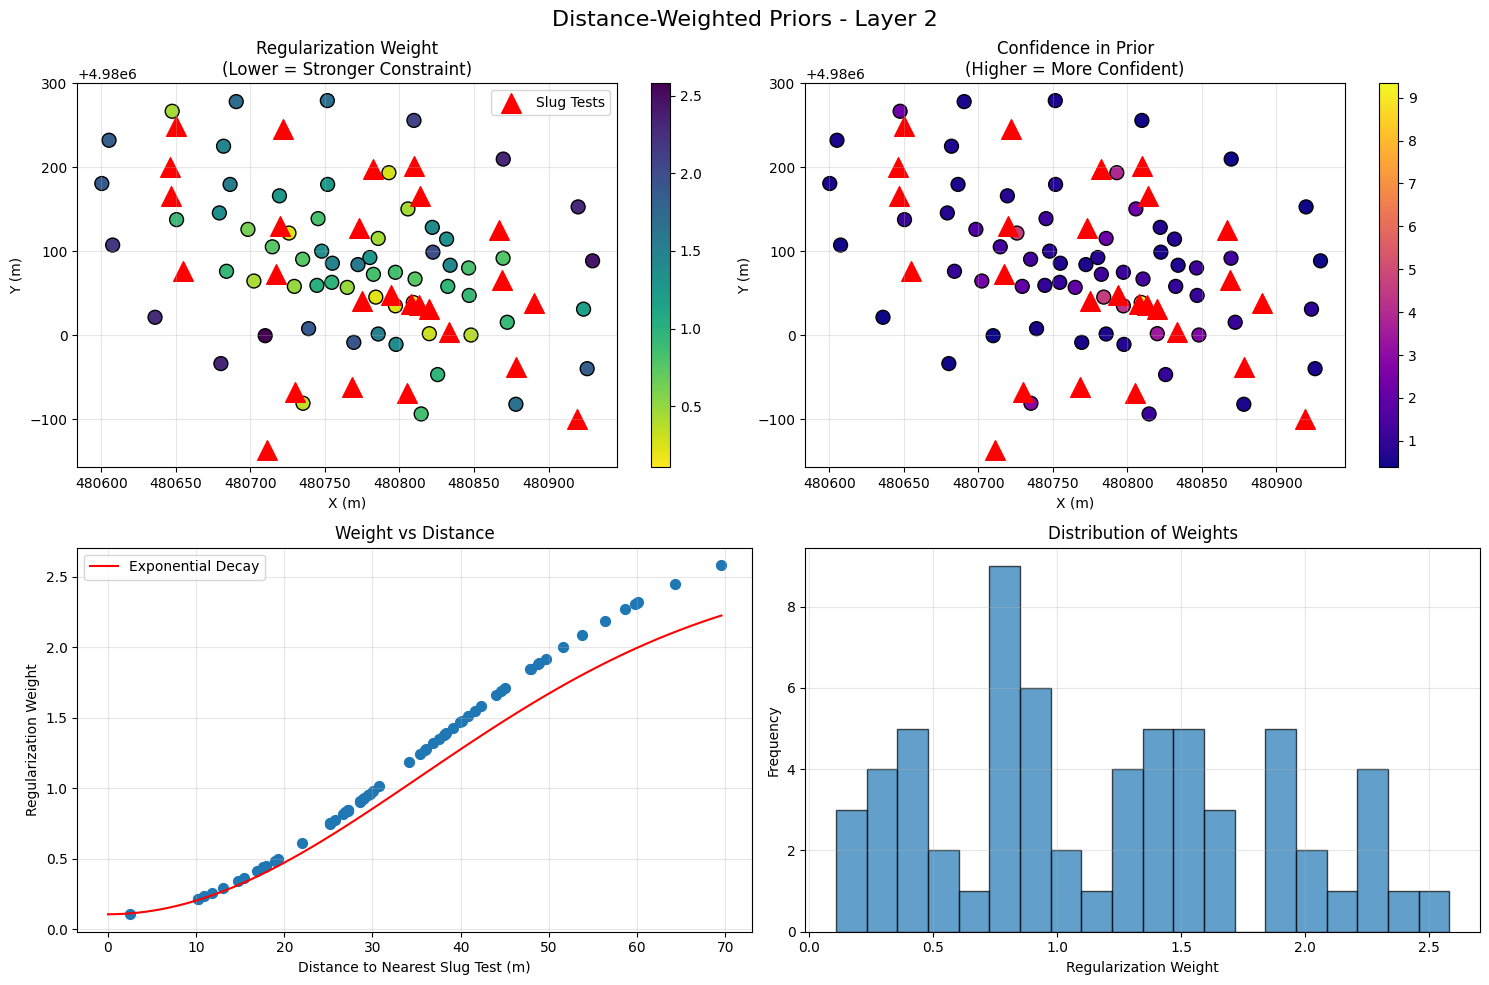


Layer 2 - Weight Statistics:
Distance Range (m)   Weight Range         Count     
--------------------------------------------------
  0 -  10      0.107 - 0.107      1         
 10 -  20      0.217 - 0.501      13        
 20 -  30      0.610 - 0.961      16        
 30 -  50      0.979 - 1.920      25        
 50 - 100      2.001 - 2.582      9         


In [97]:
visualize_distance_weights(results, layer_idx=1)

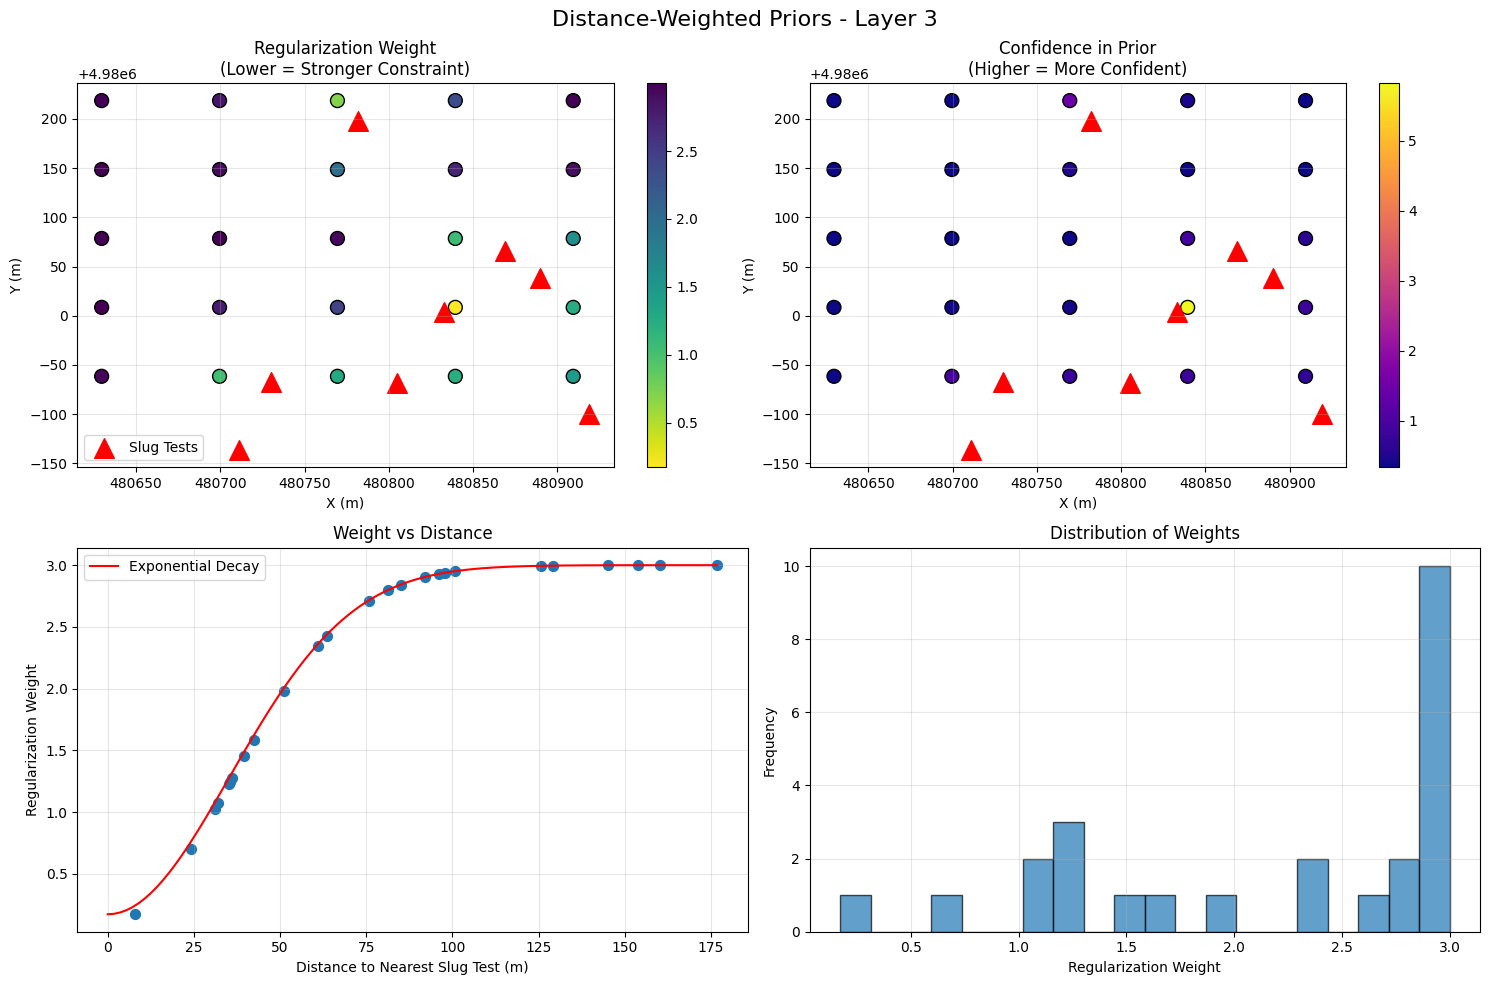


Layer 3 - Weight Statistics:
Distance Range (m)   Weight Range         Count     
--------------------------------------------------
  0 -  10      0.172 - 0.172      1         
 20 -  30      0.697 - 0.697      1         
 30 -  50      1.025 - 1.587      7         
 50 - 100      1.977 - 2.937      9         
100 - inf      2.950 - 3.000      7         


In [98]:
visualize_distance_weights(results, layer_idx=2)

In [99]:
def update_prior_weights_simple(pst, results):
    """
    Simple weight update - just updates weights in prior_information.
    Assumes results contains 'weights' arrays for each layer in order.
    """
    
    if pst.prior_information is None:
        print('no prior information found')
        return pst
    
    # Extract weights from results in layer order
    all_weights = []
    
    for layer_key in ['layer_1', 'layer_2', 'layer_3']: 
        if layer_key in results:
            layer_data = results[layer_key]
            if 'weights' in layer_data:
                all_weights.extend(layer_data['weights'].tolist())
            elif 'pilot_points' in layer_data and 'weight' in layer_data['pilot_points'].columns:
                all_weights.extend(layer_data['pilot_points']['weight'].tolist())
    
    # Update weights in prior_information (same order assumed)
    n_weights = len(all_weights)
    n_priors = len(pst.prior_information)
    
    if n_weights == 0 or n_priors == 0:
        print('no weights or priors given')
        return pst
    
    n = min(n_weights, n_priors)
    if n_priors == n_weights:
    
        for i in range(n):
            pst.prior_information.iloc[i, pst.prior_information.columns.get_loc('weight')] = all_weights[i]
        print('prior equation weights updated')
        return pst
    else: 
        print('different number of priors and new weights')

In [100]:
pst.prior_information.head()

,pilbl,equation,obgnme,weight
pilbl,,,,
p0,p0,1.0 * log(p0) = 0.000000E+00,regulpg0,0.124244
p1,p1,1.0 * log(p1) = 0.000000E+00,regulpg0,0.124244
p2,p2,1.0 * log(p2) = 0.000000E+00,regulpg0,0.124244
p3,p3,1.0 * log(p3) = 0.000000E+00,regulpg0,0.124244
p4,p4,1.0 * log(p4) = 0.000000E+00,regulpg0,0.124244


In [101]:
pst = update_prior_weights_simple(pst, results)

prior equation weights updated


In [102]:
pst.prior_information.head()

,pilbl,equation,obgnme,weight
pilbl,,,,
p0,p0,1.0 * log(p0) = 0.000000E+00,regulpg0,3.000000
p1,p1,1.0 * log(p1) = 0.000000E+00,regulpg0,2.999999
p2,p2,1.0 * log(p2) = 0.000000E+00,regulpg0,2.999980
p3,p3,1.0 * log(p3) = 0.000000E+00,regulpg0,2.999813
p4,p4,1.0 * log(p4) = 0.000000E+00,regulpg0,2.999863


In [103]:
#pst.pestpp_options.pop('n_iter_base')
#pst.pestpp_options.pop('n_iter_super')

In [104]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,p0,k_layer1_inst:0,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,p1,k_layer1_inst:0,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,p2,k_layer1_inst:0,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,p3,k_layer1_inst:0,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,p4,k_layer1_inst:0,35,0,315,k,m,pp,NaN,NaN,1


In [105]:
'''mask1 = pst.parameter_data['pargp'].str.contains('pg0', na=False)

# Calculate bounds for pg0 parameters only
if mask1.any():
    parlbnd = np.log10(pst.parameter_data.loc[mask1, 'parval1'].values) - (par_bnd_len1/2)
    parubnd = np.log10(pst.parameter_data.loc[mask1, 'parval1'].values) + (par_bnd_len1/2)
    
    # Update only the pg0 rows
    pst.parameter_data.loc[mask1, 'parlbnd'] = 10**parlbnd
    pst.parameter_data.loc[mask1, 'parubnd'] = 10**parubnd

mask2 = pst.parameter_data['pargp'].str.contains('pg1', na=False)

# Calculate bounds for pg1 parameters only
if mask2.any():
    parlbnd = np.log10(pst.parameter_data.loc[mask2, 'parval1'].values) - (par_bnd_len2/2)
    parubnd = np.log10(pst.parameter_data.loc[mask2, 'parval1'].values) + (par_bnd_len2/2)
    
    # Update only the pg1 rows
    pst.parameter_data.loc[mask2, 'parlbnd'] = 10**parlbnd
    pst.parameter_data.loc[mask2, 'parubnd'] = 10**parubnd

mask3 = pst.parameter_data['pargp'].str.contains('pg2', na=False)

# Calculate bounds for pg2 parameters only
if mask3.any():
    parlbnd = np.log10(pst.parameter_data.loc[mask3, 'parval1'].values) - (par_bnd_len3/2)
    parubnd = np.log10(pst.parameter_data.loc[mask3, 'parval1'].values) + (par_bnd_len3/2)
    
    # Update only the pg2 rows
    pst.parameter_data.loc[mask3, 'parlbnd'] = 10**parlbnd
    pst.parameter_data.loc[mask3, 'parubnd'] = 10**parubnd'''

"mask1 = pst.parameter_data['pargp'].str.contains('pg0', na=False)\n\n# Calculate bounds for pg0 parameters only\nif mask1.any():\n    parlbnd = np.log10(pst.parameter_data.loc[mask1, 'parval1'].values) - (par_bnd_len1/2)\n    parubnd = np.log10(pst.parameter_data.loc[mask1, 'parval1'].values) + (par_bnd_len1/2)\n\n    # Update only the pg0 rows\n    pst.parameter_data.loc[mask1, 'parlbnd'] = 10**parlbnd\n    pst.parameter_data.loc[mask1, 'parubnd'] = 10**parubnd\n\nmask2 = pst.parameter_data['pargp'].str.contains('pg1', na=False)\n\n# Calculate bounds for pg1 parameters only\nif mask2.any():\n    parlbnd = np.log10(pst.parameter_data.loc[mask2, 'parval1'].values) - (par_bnd_len2/2)\n    parubnd = np.log10(pst.parameter_data.loc[mask2, 'parval1'].values) + (par_bnd_len2/2)\n\n    # Update only the pg1 rows\n    pst.parameter_data.loc[mask2, 'parlbnd'] = 10**parlbnd\n    pst.parameter_data.loc[mask2, 'parubnd'] = 10**parubnd\n\nmask3 = pst.parameter_data['pargp'].str.contains('pg2', na=

In [106]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,longname,shortname,pglong,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,p0,k_layer1_inst:0,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,p1,k_layer1_inst:0,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,p2,k_layer1_inst:0,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,p3,k_layer1_inst:0,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,p4,k_layer1_inst:0,35,0,315,k,m,pp,NaN,NaN,1


overwritting pst file

In [107]:
pst.write(os.path.join(template_ws, 'mf6.pst'),version=1)

noptmax:0, npar_adj:114, nnz_obs:120


setting up agents for running PEST in parallel

In [108]:
#number of cores availables
psutil.cpu_count(logical=False)

10

In [109]:
#setting the number of workers
num_workers = 10

In [110]:
#run-manager directory folder (where the manager will be running), 
#outcomes of PEST will be recorded here in a different location than template_ws to avoid mistakes
m_d = 'master_pp'

when running from jupyter notebook slow things down a lot, it is better as the model get complex to run from command lines which is faster and more efficient

Starting workers and running PEST

In [111]:
pyemu.os_utils.start_workers(template_ws, # folder which contains the "template" PEST dataset
                            'pestpp-glm', #PEST software version we want to run
                            'mf6.pst', #PEST control file 
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d, #manager directory where it will be running
                            verbose=True,
                            )

2026-02-27 14:37:40,604 - MainProcess - INFO - Reserved port 4190 for process 34064


master:pestpp-glm mf6.pst /h :4190 in master_pp
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_0
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_1
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_2
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_3
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_4
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_5
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_6
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_7
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_8
worker:pestpp-glm mf6.pst /h localhost:4190 in .\worker_9


Running PEST #old

In [112]:
#pyemu.os_utils.run('pestpp-glm PMW-6_mf6.pst', cwd=template_ws, verbose=True)

plotting results

In [113]:
df_obj = pd.read_csv(os.path.join(m_d, "mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,ob1,ob0,ob2,regulpg0,regulpg1,regulpg2
iteration,,,,,,,,,,
0,1,1.62872,1.62872,0,1.58693,0.022959,0.018837,0,0,0


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

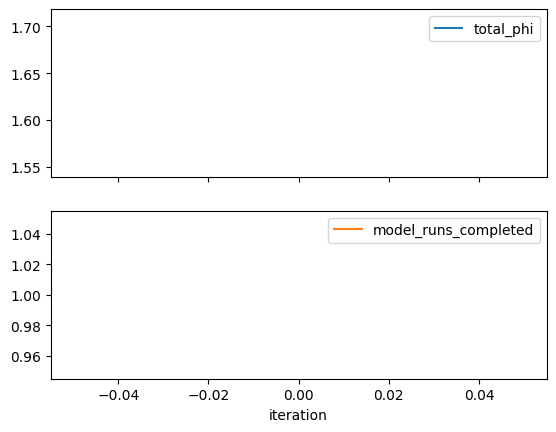

In [114]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

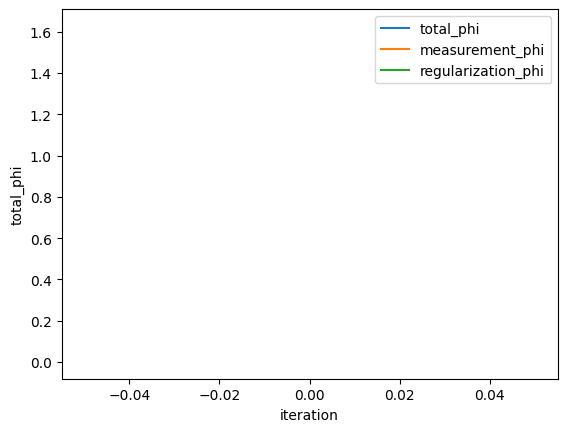

In [115]:
df_obj.plot(y=['total_phi','measurement_phi','regularization_phi'])
plt.ylabel('total_phi');

loading pst

In [116]:
pst = pyemu.Pst(os.path.join(m_d, 'mf6.pst'))

In [117]:
pst.phi

np.float64(1.6287242617326754)

Estimated K values:

In [118]:
pst.parrep(os.path.join(m_d, "mf6.par" ))
pst.write_input_files(pst_path=m_d)
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer1_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer1.txt"))

Updating parameter values from master_pp\mf6.par
parrep: updating noptmax to 0


'master_pp\\k_layer1.txt'

Layer 2 

In [119]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer2_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer2_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer2.txt"))

'master_pp\\k_layer2.txt'

In [120]:
pyemu.geostats.fac2real(os.path.join(m_d,"k_layer3_inst0pp.dat"),
                        factors_file=os.path.join(m_d,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d,"k_layer3.txt"))

'master_pp\\k_layer3.txt'

In [121]:
pst.parameter_data.parval1

parnme
p0        1.000000
p1        1.000000
p2        1.000000
p3        1.000000
p4        1.000000
p5        1.000000
p6        1.000000
p7        1.000000
p8        1.000000
p9        1.000000
p10       1.000000
p11       1.000000
p12       1.000000
p13       1.000000
p14       1.000000
p15       1.000000
p16       1.000000
p17       1.000000
p18       1.000000
p19       1.000000
p20       1.000000
p21       1.000000
p22       1.000000
p23       1.000000
p24       1.000000
p25     100.000000
p26     100.000000
p27     100.000000
p28     100.000000
p29     100.000000
p30     100.000000
p31     100.000000
p32     100.000000
p33     100.000000
p34     100.000000
p35     100.000000
p36     100.000000
p37     100.000000
p38     100.000000
p39     100.000000
p40     100.000000
p41     100.000000
p42     100.000000
p43     100.000000
p44     100.000000
p45     100.000000
p46     100.000000
p47     100.000000
p48     100.000000
p49     100.000000
p50     100.000000
p51     100.000000
p52  

In [122]:
import seaborn as sns

<Axes: >

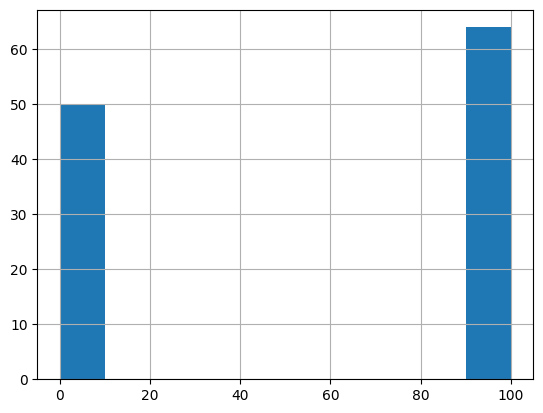

In [123]:
pst.parameter_data.parval1.hist()

In [124]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,extra,longname,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,1.0,0.000095,10576.773633,pg0,1.0,0.0,1,NaN,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,35,0,315,k,m,pp,NaN,NaN,1


<Axes: xlabel='parval1', ylabel='Count'>

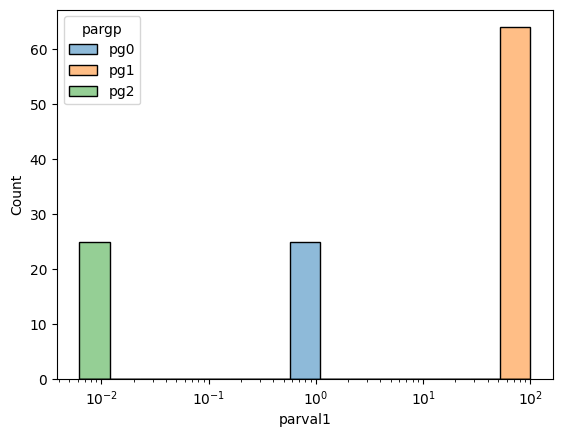

In [125]:
sns.histplot(data=pst.parameter_data, x='parval1', hue='pargp', bins=15, log_scale=True)

In [126]:
estimated_parameters = pst.parameter_data.copy()
10**(estimated_parameters.loc[estimated_parameters['partrans'] == 'log', 'parval1'])


parnme
p0       1.000000e+01
p1       1.000000e+01
p2       1.000000e+01
p3       1.000000e+01
p4       1.000000e+01
p5       1.000000e+01
p6       1.000000e+01
p7       1.000000e+01
p8       1.000000e+01
p9       1.000000e+01
p10      1.000000e+01
p11      1.000000e+01
p12      1.000000e+01
p13      1.000000e+01
p14      1.000000e+01
p15      1.000000e+01
p16      1.000000e+01
p17      1.000000e+01
p18      1.000000e+01
p19      1.000000e+01
p20      1.000000e+01
p21      1.000000e+01
p22      1.000000e+01
p23      1.000000e+01
p24      1.000000e+01
p25     1.000000e+100
p26     1.000000e+100
p27     1.000000e+100
p28     1.000000e+100
p29     1.000000e+100
p30     1.000000e+100
p31     1.000000e+100
p32     1.000000e+100
p33     1.000000e+100
p34     1.000000e+100
p35     1.000000e+100
p36     1.000000e+100
p37     1.000000e+100
p38     1.000000e+100
p39     1.000000e+100
p40     1.000000e+100
p41     1.000000e+100
p42     1.000000e+100
p43     1.000000e+100
p44     1.000000e+100
p45

plotting head results

In [127]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
res_nz.head(4)

,name,group,measured,modelled,residual,weight
name,,,,,,
ob0,ob0,ob1,0.010999,0.000579,0.010420,1.0
ob1,ob1,ob1,0.022082,0.000582,0.021500,1.0
ob2,ob2,ob1,0.037808,0.000585,0.037223,1.0
ob3,ob3,ob1,0.049898,0.000587,0.049312,1.0


<Figure size 800x1050 with 0 Axes>

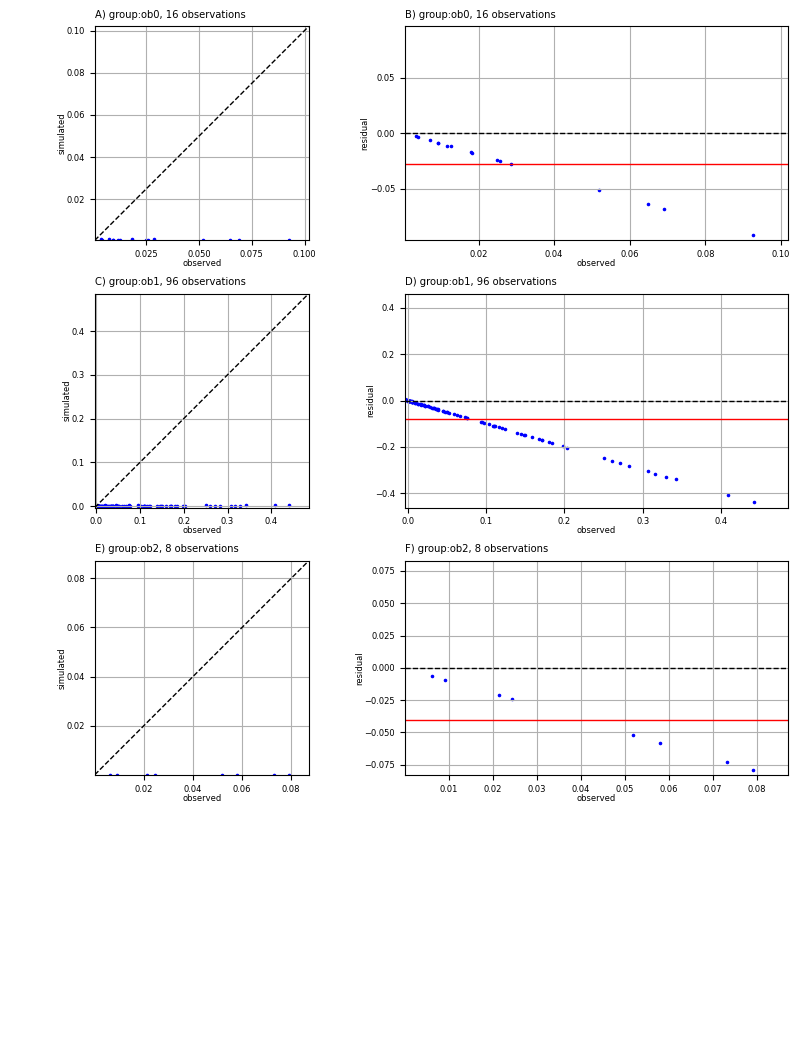

In [128]:
pyemu.plot_utils.res_1to1(pst);

In [129]:
pst.phi

np.float64(1.6287242617326754)

plotting estimated K field

In [130]:
sim_path = os.path.join(m_d, "3d_injection_modeling_PMW-3")
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_path)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


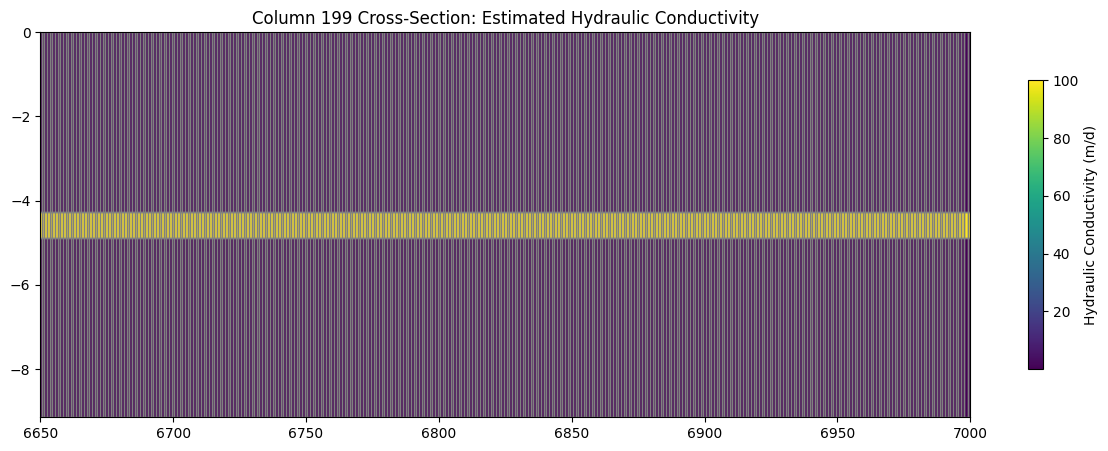

In [131]:
hk_array = gwf.npf.k.array

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1)

# Create a PlotCrossSection object for a specific column
xsect = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"Column": 199})

# Plot the hydraulic conductivity array on the cross-section
# The plot_array() method will display the values as colored patches
csa = xsect.plot_array(hk_array)

# Plot the model grid for context
linecollection = xsect.plot_grid()

# Add a color bar to interpret the hydraulic conductivity values
cb = plt.colorbar(csa, shrink=0.75, label="Hydraulic Conductivity (m/d)")

# Set the title and show the plot
ax.set_title("Column 199 Cross-Section: Estimated Hydraulic Conductivity")
ax.set_xlim(6650, 7000) # Assuming the same x-limits as your previous plot
plt.show()

whole field

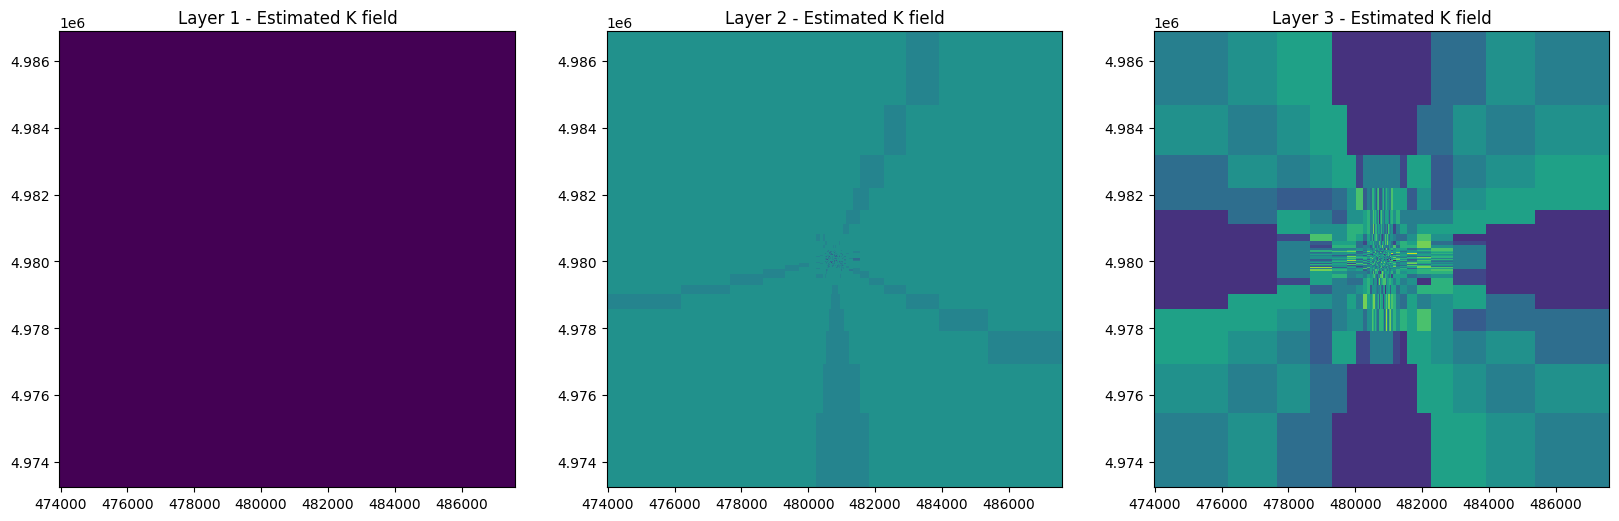

In [132]:
fig = plt.figure(figsize=(20, 20))
for i in range(3):
    
    ax = fig.add_subplot(1, 3, i+1, aspect='equal')

    # Create a PlotMapView object
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)

    # Plot the active and inactive cells
    # In MODFLOW 6, 'IDOMAIN' array is used instead of 'IBOUND'.
    # plot_ibound() handles this automatically.
    quadmesh = mapview.plot_array(hk_array[i]) # plots K field

    # Plot the grid lines for context
    #grid_lines = mapview.plot_grid()

    # Add a title and show the plot
    ax.set_title(f"Layer {i+1} - Estimated K field")
    #plt.show()

zoom at MLAC site

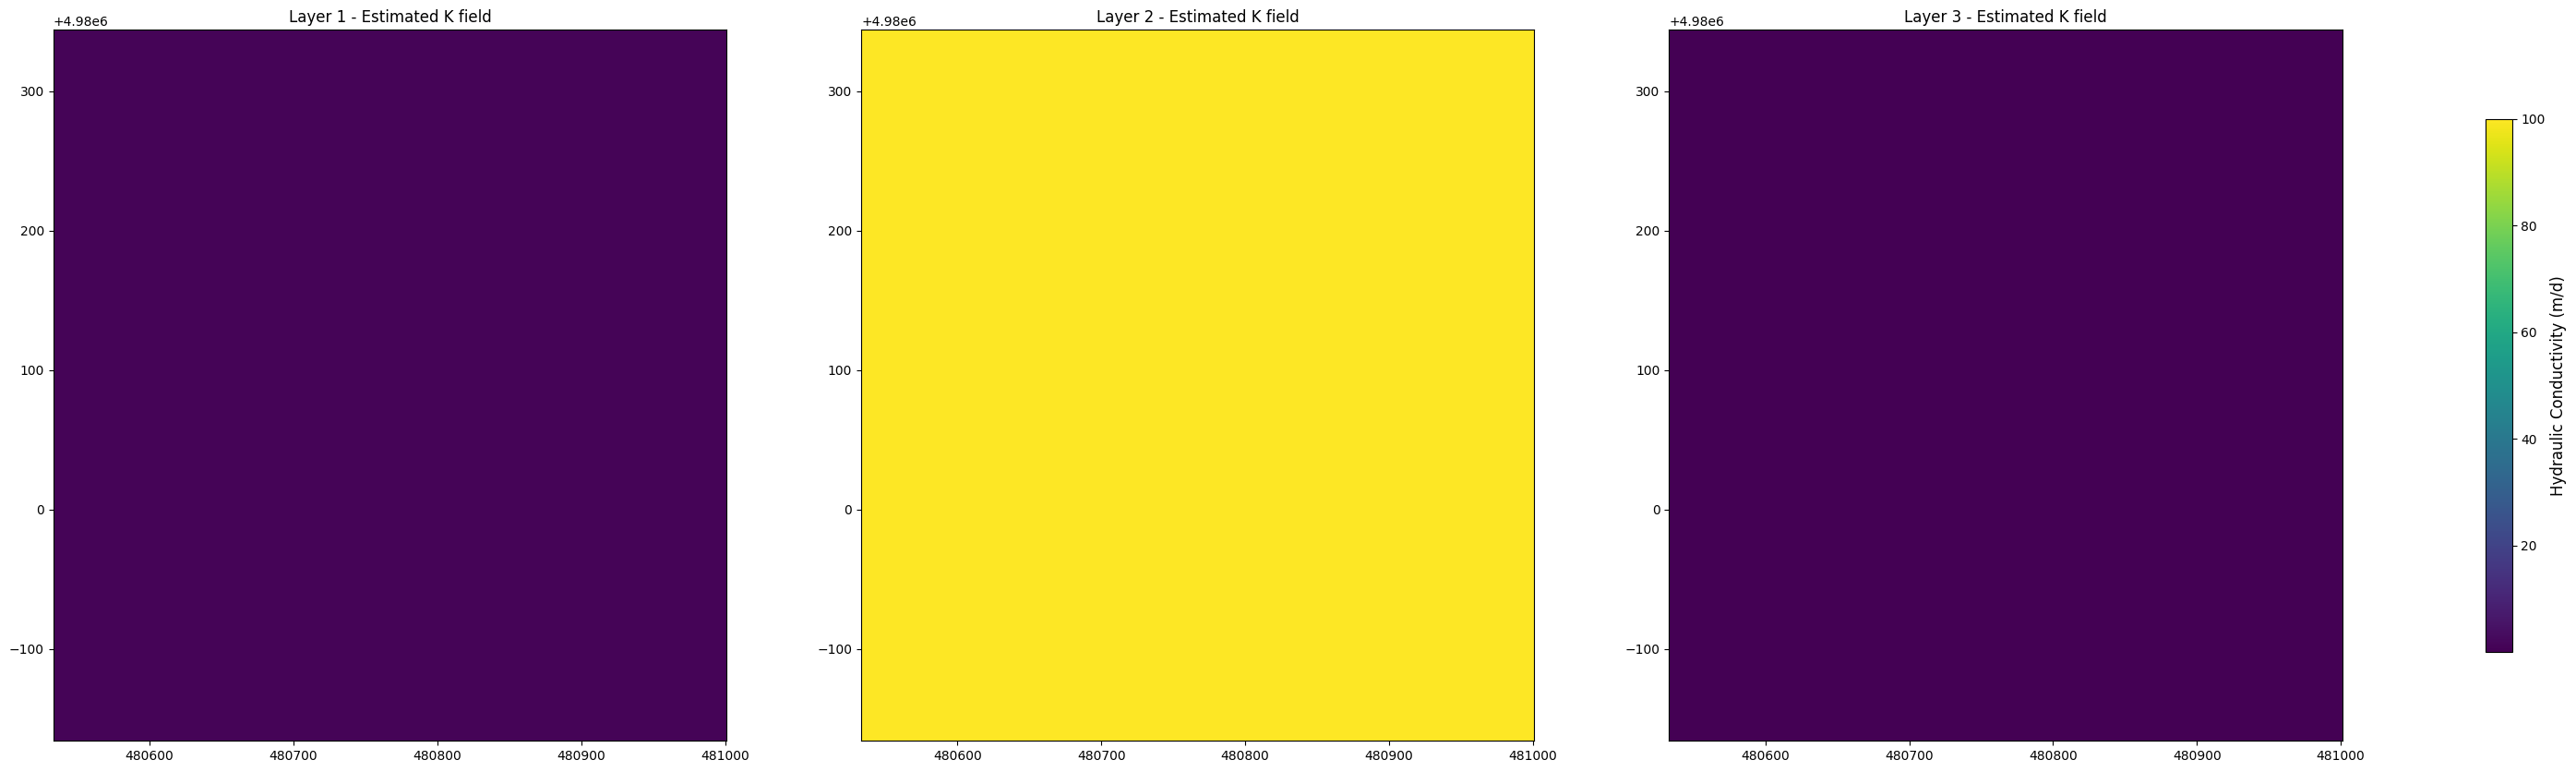

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
vmin = hk_array.min()
vmax = hk_array.max()

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    quadmesh = mapview.plot_array(hk_array[i], vmin=vmin, vmax=vmax)
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

In [134]:
from matplotlib.colors import LogNorm 

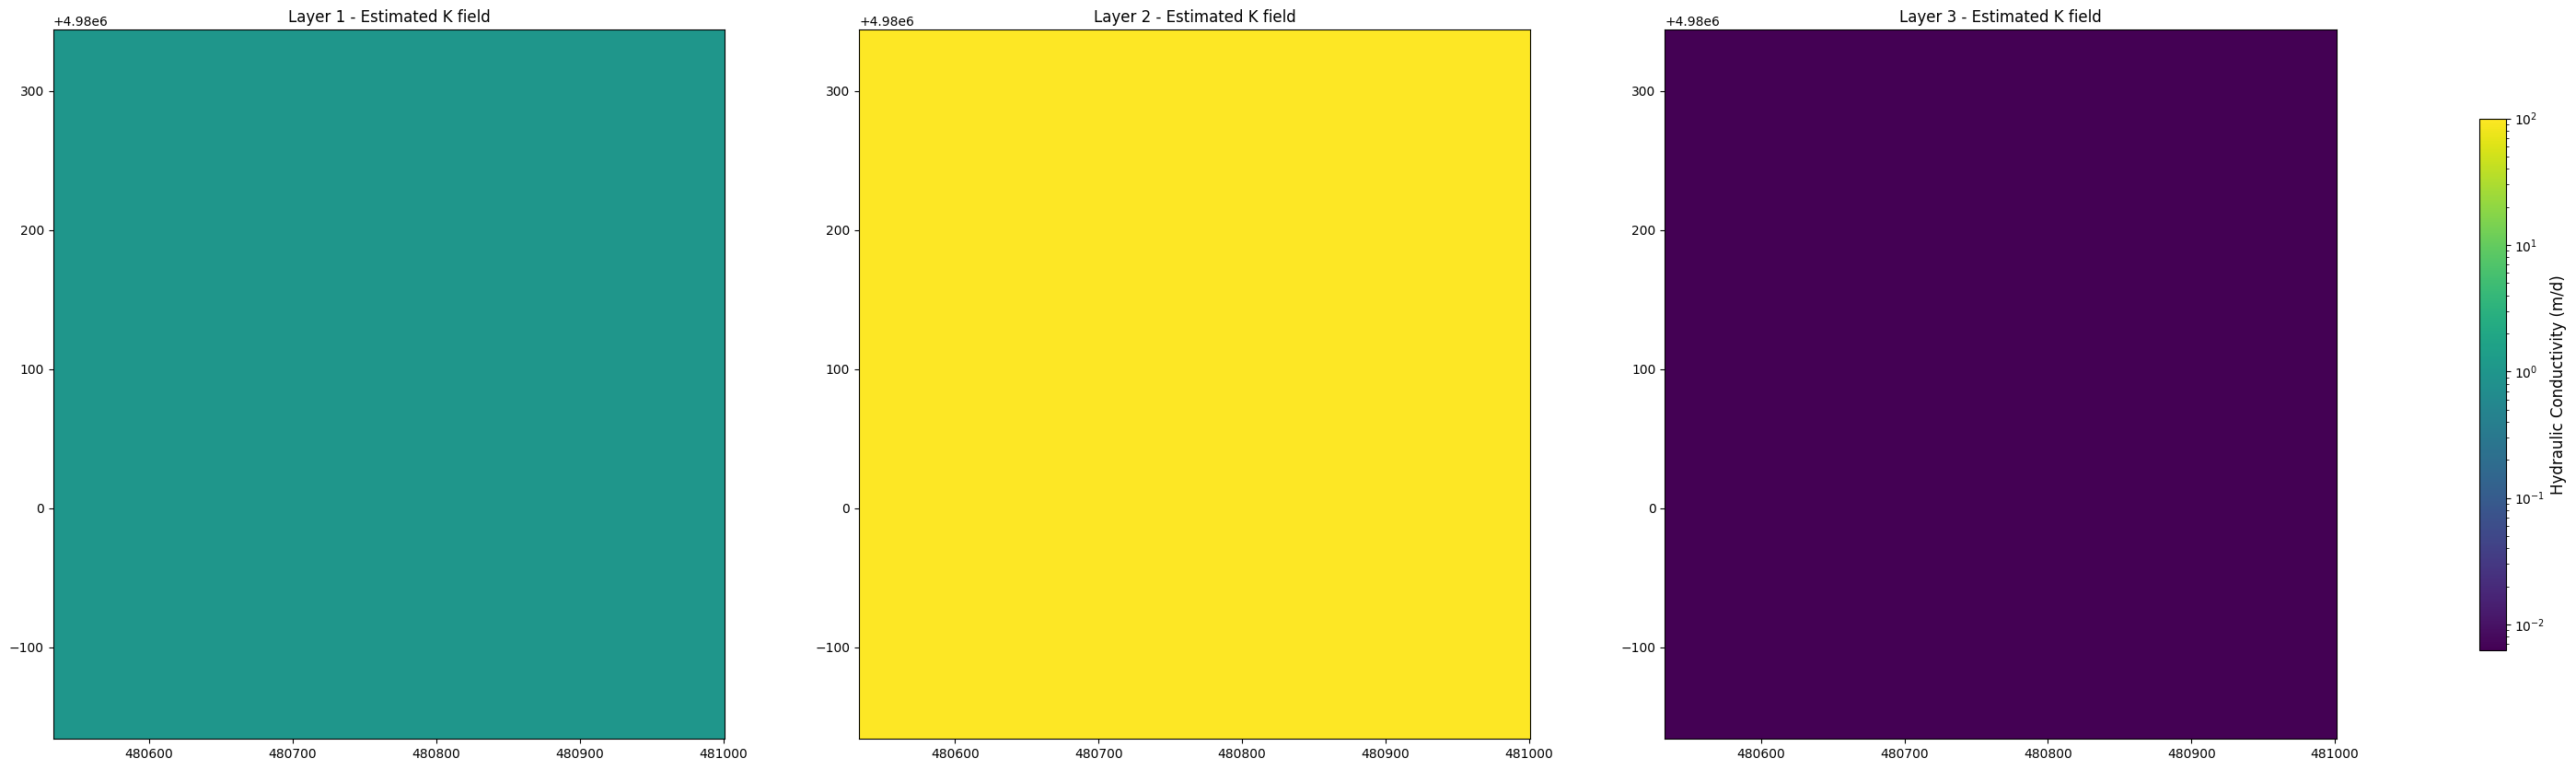

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
# These values MUST be positive for a log scale to work
vmin = hk_array.min()
vmax = hk_array.max()

# Ensure vmin is greater than 0, which hydraulic conductivity should be
if vmin <= 0:
    print(f"Warning: vmin ({vmin}) is <= 0. Adjusting to a small positive value for log scaling.")
    vmin = 1e-3 # Or some other appropriate small positive number

# Define the logarithmic normalization object
norm = LogNorm(vmin=vmin, vmax=vmax)

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    
    # Pass the 'norm' object to plot_array()
    quadmesh = mapview.plot_array(hk_array[i], norm=norm) 
    
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
# The colorbar automatically uses the norm associated with the quadmesh
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

Adjusting observation weights (this need to be done after running a initial inversion NONPT = 0)

example that used this: https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024WR038048?af=R#:~:text=The%20outcomes%20of%20the%20event,the%20desired%20balance%20is%20obtained.

In [136]:
pst.nnz_obs_groups

['ob1', 'ob0', 'ob2']

In [137]:
balanced_groups = {grp:10 for grp in pst.nnz_obs_groups}
balanced_groups


{'ob1': 10, 'ob0': 10, 'ob2': 10}

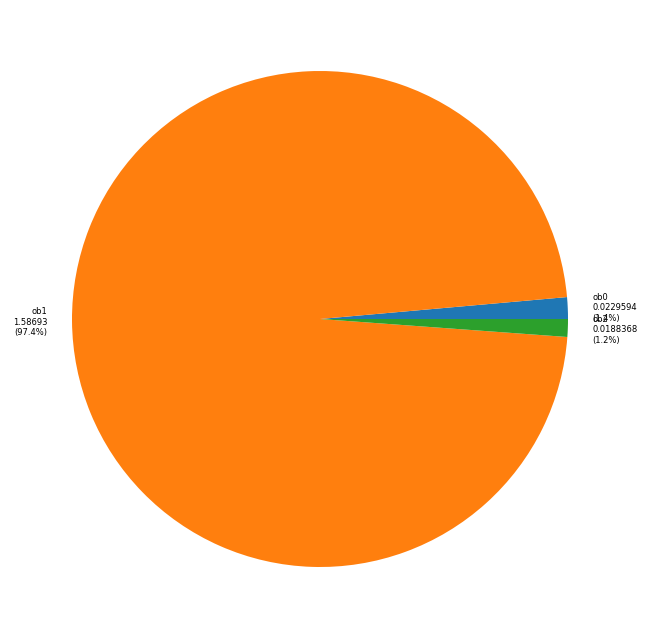

In [138]:
pst.plot(kind="phi_pie");

In [139]:
pst.adjust_weights(obsgrp_dict=balanced_groups,)

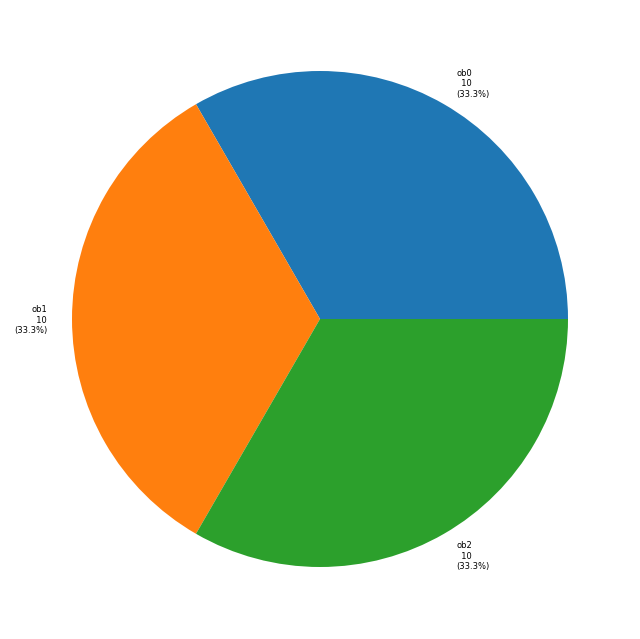

In [140]:
pst.plot(kind="phi_pie");

In [141]:
pst.control_data.noptmax = 20 # change accondily
pst.control_data.noptmax

np.int32(20)

REMOVING AUTOMATIC ADJUSTMENT OF PHI_r TO ACHIEVE THE TARGET PHI_m, so lambda (regul weight for Pareto) will be constant throughout the pest simulation

In [151]:
print(pst.control_data.__dict__)


{'formatters': {<class 'numpy.int32'>: <function <lambda> at 0x0000028AF0ABAF20>, <class 'numpy.float64'>: <function <lambda> at 0x0000028AF0ABAFC0>, <class 'str'>: <function <lambda> at 0x0000028AF0ABADE0>}, '_df':                           name                     type           value  required                                     format  passed
name                                                                                                                                
rstfle                  rstfle            <class 'str'>         restart      True  <function <lambda> at 0x0000028AF0ABADE0>    True
pestmode              pestmode            <class 'str'>  regularization      True  <function <lambda> at 0x0000028AF0ABADE0>    True
npar                      npar    <class 'numpy.int32'>             114      True  <function <lambda> at 0x0000028AF0ABAF20>    True
nobs                      nobs    <class 'numpy.int32'>             120      True  <function <lambda> at 0x0000028AF0AB

In [155]:
lam = 1.0  #Pareto lambda

#to freeze the GLM regularization weight
pst.pestpp_options["glm_reg_factor"] = lam
pst.pestpp_options["glm_reg_fmin"] = lam
pst.pestpp_options["glm_reg_fmax"] = lam

# Disable automatic adjustment
pst.pestpp_options["frcphim"] = 0.0
pst.pestpp_options["glm_num_recalc"] = 0


In [156]:
pst.pestpp_options

{'glm_reg_factor': 1.0,
 'glm_reg_fmin': 1.0,
 'glm_reg_fmax': 1.0,
 'frcphim': 0.0,
 'glm_num_recalc': 0}

In [142]:
m_d2 = 'master_pp_pareto_newinitialK_1_100_1E-2'

In [143]:
pst.write(os.path.join(m_d, 'mf6.pst'),version=1)

noptmax:20, npar_adj:114, nnz_obs:120


In [ ]:
pyemu.os_utils.start_workers(m_d, # folder which contains the "template" PEST dataset
                            'pestpp-glm', #PEST software version we want to run
                            'mf6.pst', #PEST control file 
                            num_workers=num_workers, #how many agents to deploy
                            worker_root='.', #where to deploy the agent directories; relative to where python is running
                            master_dir=m_d2, #manager directory where it will be running
                            verbose=True,
                            )

2026-02-27 14:47:58,682 - MainProcess - INFO - Reserved port 4509 for process 34064


master:pestpp-glm mf6.pst /h :4509 in master_pp_pareto_newinitialK_1_100_1E-2
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_0
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_1
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_2
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_3
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_4
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_5
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_6
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_7
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_8
worker:pestpp-glm mf6.pst /h localhost:4509 in .\worker_9


md3

In [162]:
df_obj = pd.read_csv(os.path.join(m_d2, "mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,ob1,ob0,ob2,regulpg0,regulpg1,regulpg2
iteration,,,,,,,,,,
0,0,35.7878,30.0011,5.78674,9.99999,9.99997,10.0011,0.000000,0.000000,5.78674
1,129,35.8005,30.0119,5.78862,10.00310,10.00770,10.0011,0.000921,0.000957,5.78674
2,260,35.7975,30.0089,5.78864,10.00120,10.00660,10.0011,0.000925,0.000978,5.78674
3,509,35.7819,29.9934,5.78855,9.99694,9.99540,10.0010,0.000974,0.000839,5.78674


In [196]:
#m_d3 = 'master_pp_newweights_newinitialK' #with prior

m_d3 = 'master_pp3_no_ss_no_prior' #without prior

In [163]:
pst = pyemu.Pst(os.path.join(m_d2, 'mf6.pst'))

In [164]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]

In [165]:
%matplotlib inline

<Figure size 800x1050 with 0 Axes>

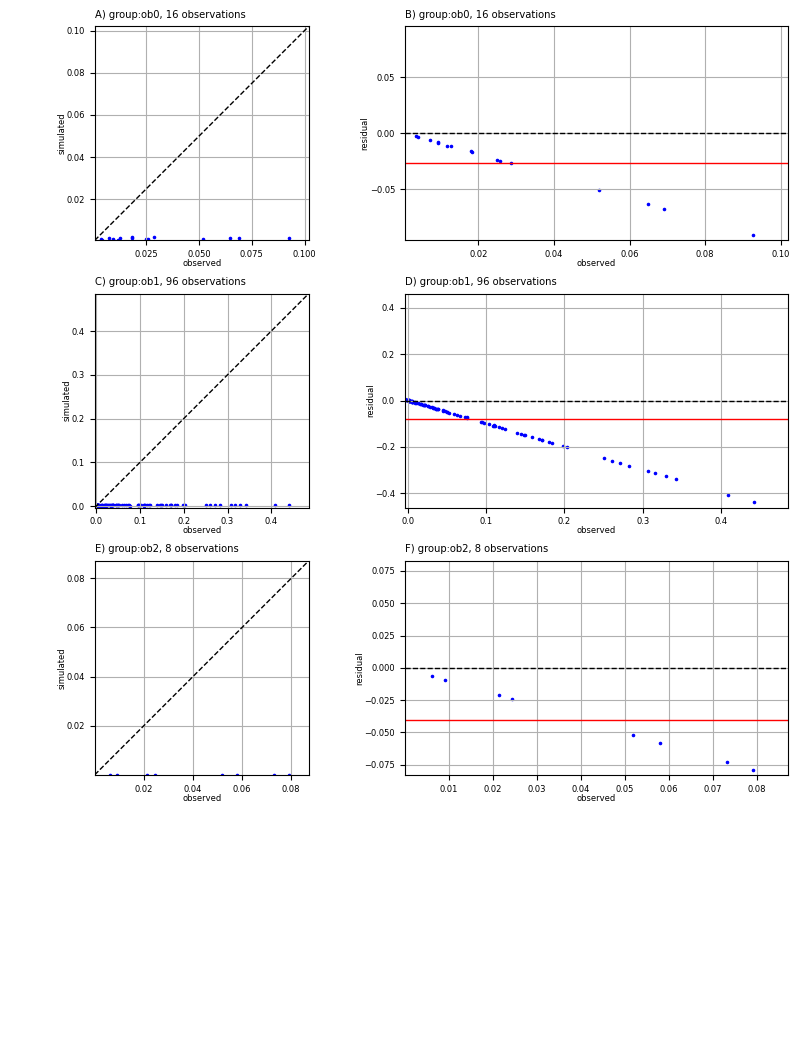

In [166]:
pyemu.plot_utils.res_1to1(pst, fontsize=80);

Checking results, do another for md3 sim without ss

In [202]:
df_obj = pd.read_csv(os.path.join(m_d3, "mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,ob1,ob0,ob2
iteration,,,,,,,
0,0,30.00000,30.00000,0,10.00000,10.00000,10.00000
1,129,27.98680,27.98680,0,9.98820,9.68517,8.31338
2,260,26.12210,26.12210,0,9.71102,8.62529,7.78583
3,508,22.34920,22.34920,0,9.31566,7.28389,5.74967
4,757,15.61220,15.61220,0,8.31943,4.47244,2.82031
5,1006,12.81180,12.81180,0,7.48087,3.80675,1.52423
6,1254,10.53730,10.53730,0,5.84271,3.42883,1.26573
7,1501,10.19010,10.19010,0,5.58565,3.40304,1.20146
8,1744,10.15730,10.15730,0,5.47102,3.40201,1.28427


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

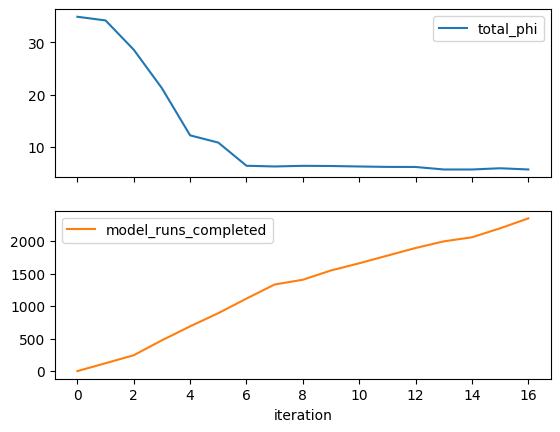

In [65]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

Text(0.5, 1.0, 'Phi evolution - without prior')

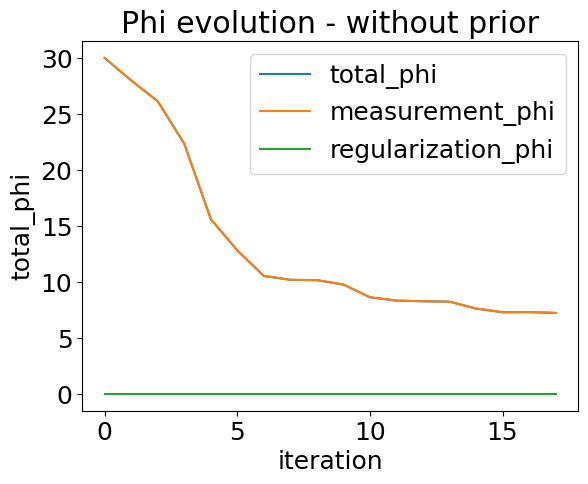

In [203]:
df_obj.plot(y=['total_phi','measurement_phi','regularization_phi'])
plt.ylabel('total_phi');
plt.title(f'Phi evolution - without prior')
#plt.yscale("log")

In [117]:
pst = pyemu.Pst(os.path.join(m_d3, 'mf6.pst'))

In [118]:
pst.control_data.rlambda1

20.0

In [100]:
m_d3

'master_pp3_no_ss_no_prior'

In [152]:
pst.parrep(os.path.join(m_d3, "mf6.par" ))
pst.write_input_files(pst_path=m_d3)
pyemu.geostats.fac2real(os.path.join(m_d3,"k_layer1_inst0pp.dat"),
                        factors_file=os.path.join(m_d3,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d3,"k_layer1.txt"))

Updating parameter values from master_pp3_no_ss_no_prior\mf6.par
parrep: updating noptmax to 0


'master_pp3_no_ss_no_prior\\k_layer1.txt'

In [149]:
pyemu.geostats.fac2real(os.path.join(m_d3,"k_layer2_inst0pp.dat"),
                        factors_file=os.path.join(m_d3,"k_layer2_inst0pp.fac"),
                        out_file=os.path.join(m_d3,"k_layer2.txt"))

'master_pp3_no_ss_no_prior\\k_layer2.txt'

In [150]:
pyemu.geostats.fac2real(os.path.join(m_d3,"k_layer3_inst0pp.dat"),
                        factors_file=os.path.join(m_d3,"k_layer1_inst0pp.fac"),
                        out_file=os.path.join(m_d3,"k_layer3.txt"))

'master_pp3_no_ss_no_prior\\k_layer3.txt'

In [122]:
pst.parameter_data.parval1

parnme
p0       18.019792
p1        1.698870
p2        2.915650
p3       90.693351
p4       13.647980
p5       63.868300
p6        0.331418
p7        0.283663
p8        0.504705
p9        7.102181
p10       0.586277
p11       0.406174
p12       0.042864
p13       0.244225
p14       0.000234
p15      91.269790
p16       3.481096
p17       0.705992
p18       3.463226
p19       7.375547
p20       8.821845
p21      13.352972
p22      18.509550
p23       1.612331
p24      43.718691
p25     320.435671
p26     492.051372
p27       0.064814
p28      35.000547
p29       0.011100
p30       6.557999
p31     397.812550
p32     173.475798
p33       5.409940
p34     675.277973
p35       0.034388
p36       0.215424
p37       2.574105
p38       0.081664
p39       0.233055
p40       0.015669
p41     981.662244
p42       0.431785
p43      10.776700
p44       0.343162
p45       0.059160
p46       1.114410
p47       1.274870
p48     269.214930
p49       0.058710
p50      56.928405
p51       0.757748
p52  

<Axes: >

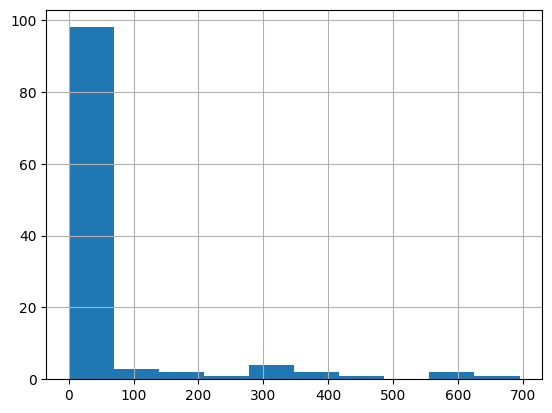

In [135]:
import seaborn as sns
pst.parameter_data.parval1.hist()

In [136]:
pst.parameter_data.head()

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,...,longname,i,inst,j,pname,pstyle,ptype,x,y,zone
parnme,,,,,,,,,,,,,,,,,,,,,
p0,p0,log,factor,77.791670,0.001704,190591.257250,pg0,1.0,0.0,1,...,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,35,0,35,k,m,pp,NaN,NaN,1
p1,p1,log,factor,1.155040,0.000161,17968.563421,pg0,1.0,0.0,1,...,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,35,0,105,k,m,pp,NaN,NaN,1
p2,p2,log,factor,6.234920,0.000276,30838.170042,pg0,1.0,0.0,1,...,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,35,0,175,k,m,pp,NaN,NaN,1
p3,p3,log,factor,289.248212,0.008575,959243.044820,pg0,1.0,0.0,1,...,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,35,0,245,k,m,pp,NaN,NaN,1
p4,p4,log,factor,15.063519,0.001290,144351.597740,pg0,1.0,0.0,1,...,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,35,0,315,k,m,pp,NaN,NaN,1


In [137]:
pst.parameter_data['pargp']

parnme
p0      pg0
p1      pg0
p2      pg0
p3      pg0
p4      pg0
       ... 
p109    pg2
p110    pg2
p111    pg2
p112    pg2
p113    pg2
Name: pargp, Length: 114, dtype: object

(1e-05, 1000.0)

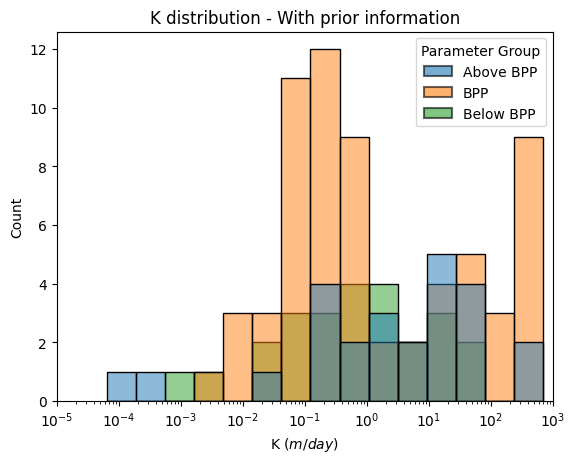

In [139]:
ax = sns.histplot(data=pst.parameter_data, x='parval1', hue='pargp', bins=15, log_scale=True, legend='full')
ax.set_xlabel(r'K ($m/day$)')
'''ax.legend(
    title='Parameter Group', 
    labels=['Below BPP', 'BPP', 'Above BPP'],
    )'''

unique_groups = pst.parameter_data['pargp'].unique()
colors = sns.color_palette(n_colors=len(unique_groups))
handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(unique_groups))]
for handle in handles:
    handle.set_alpha(0.6)  # transparency
    handle.set_edgecolor('black')
    handle.set_linewidth(1.5)
ax.legend(handles, ['Above BPP', 'BPP', 'Below BPP'], title='Parameter Group')



ax.set_title("K distribution - With prior information")
ax.set_xlim(left=1.e-5, right=1.e+3)

In [24]:
#res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
#res_nz

<Figure size 800x1050 with 0 Axes>

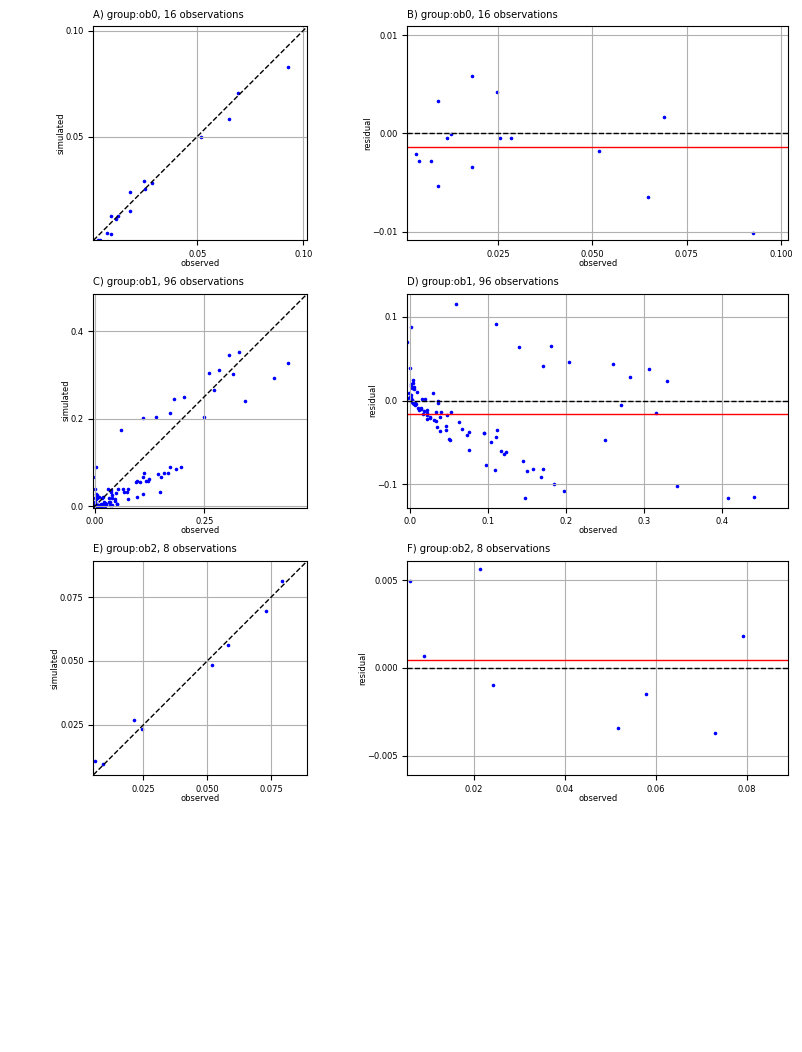

In [193]:
#plt.figure(figsize=(10, 20))
#plt.rcParams.update({'font.size': 18})
pyemu.plot_utils.res_1to1(pst);

In [204]:
sim_path = os.path.join(m_d3, "3d_injection_modeling_PMW-3")
sim = flopy.mf6.MFSimulation.load(sim_ws=sim_path)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


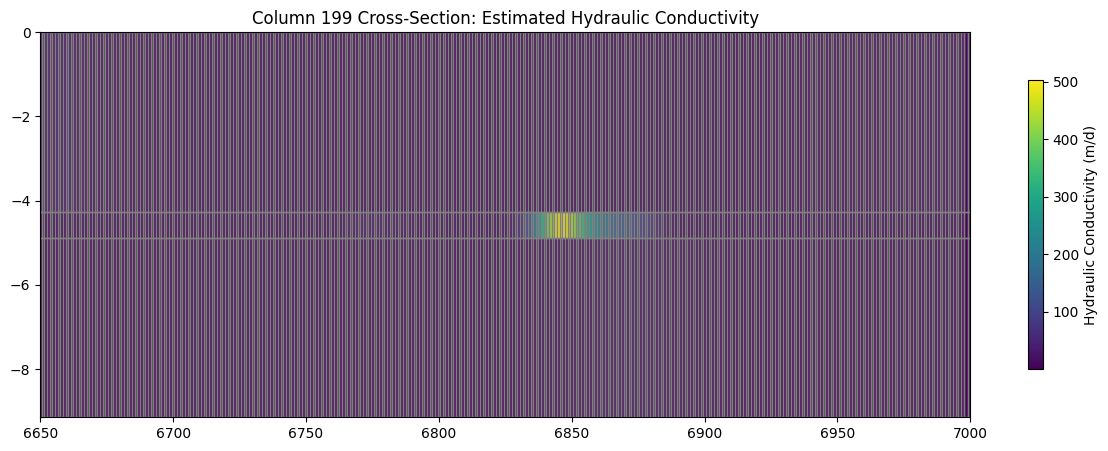

In [177]:
hk_array = gwf.npf.k.array

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1)

# Create a PlotCrossSection object for a specific column
xsect = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"Column": 199})

# Plot the hydraulic conductivity array on the cross-section
# The plot_array() method will display the values as colored patches
csa = xsect.plot_array(hk_array)

# Plot the model grid for context
linecollection = xsect.plot_grid()

# Add a color bar to interpret the hydraulic conductivity values
cb = plt.colorbar(csa, shrink=0.75, label="Hydraulic Conductivity (m/d)")

# Set the title and show the plot
ax.set_title("Column 199 Cross-Section: Estimated Hydraulic Conductivity")
ax.set_xlim(6650, 7000) # Assuming the same x-limits as your previous plot
plt.show()

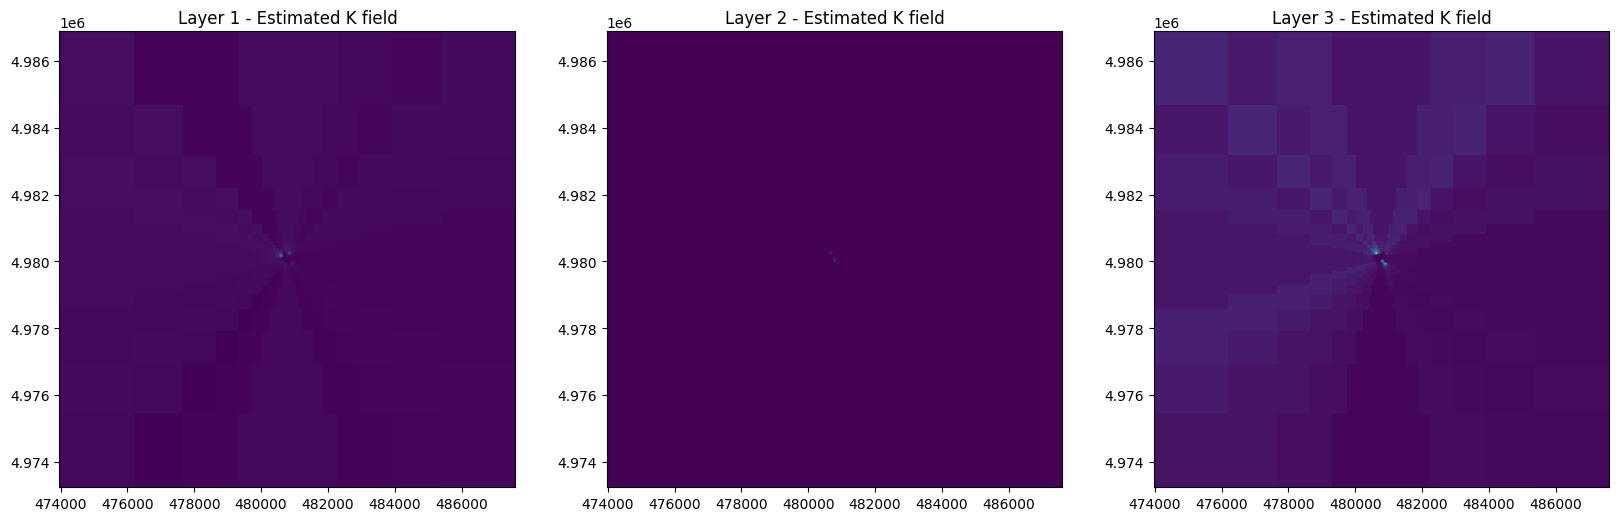

In [143]:
hk_array = gwf.npf.k.array
fig = plt.figure(figsize=(20, 20))
for i in range(3):
    
    ax = fig.add_subplot(1, 3, i+1, aspect='equal')

    # Create a PlotMapView object
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)

    # Plot the active and inactive cells
    # In MODFLOW 6, 'IDOMAIN' array is used instead of 'IBOUND'.
    # plot_ibound() handles this automatically.
    quadmesh = mapview.plot_array(hk_array[i]) # plots K field

    # Plot the grid lines for context
    #grid_lines = mapview.plot_grid()

    # Add a title and show the plot
    ax.set_title(f"Layer {i+1} - Estimated K field")
    #plt.show()

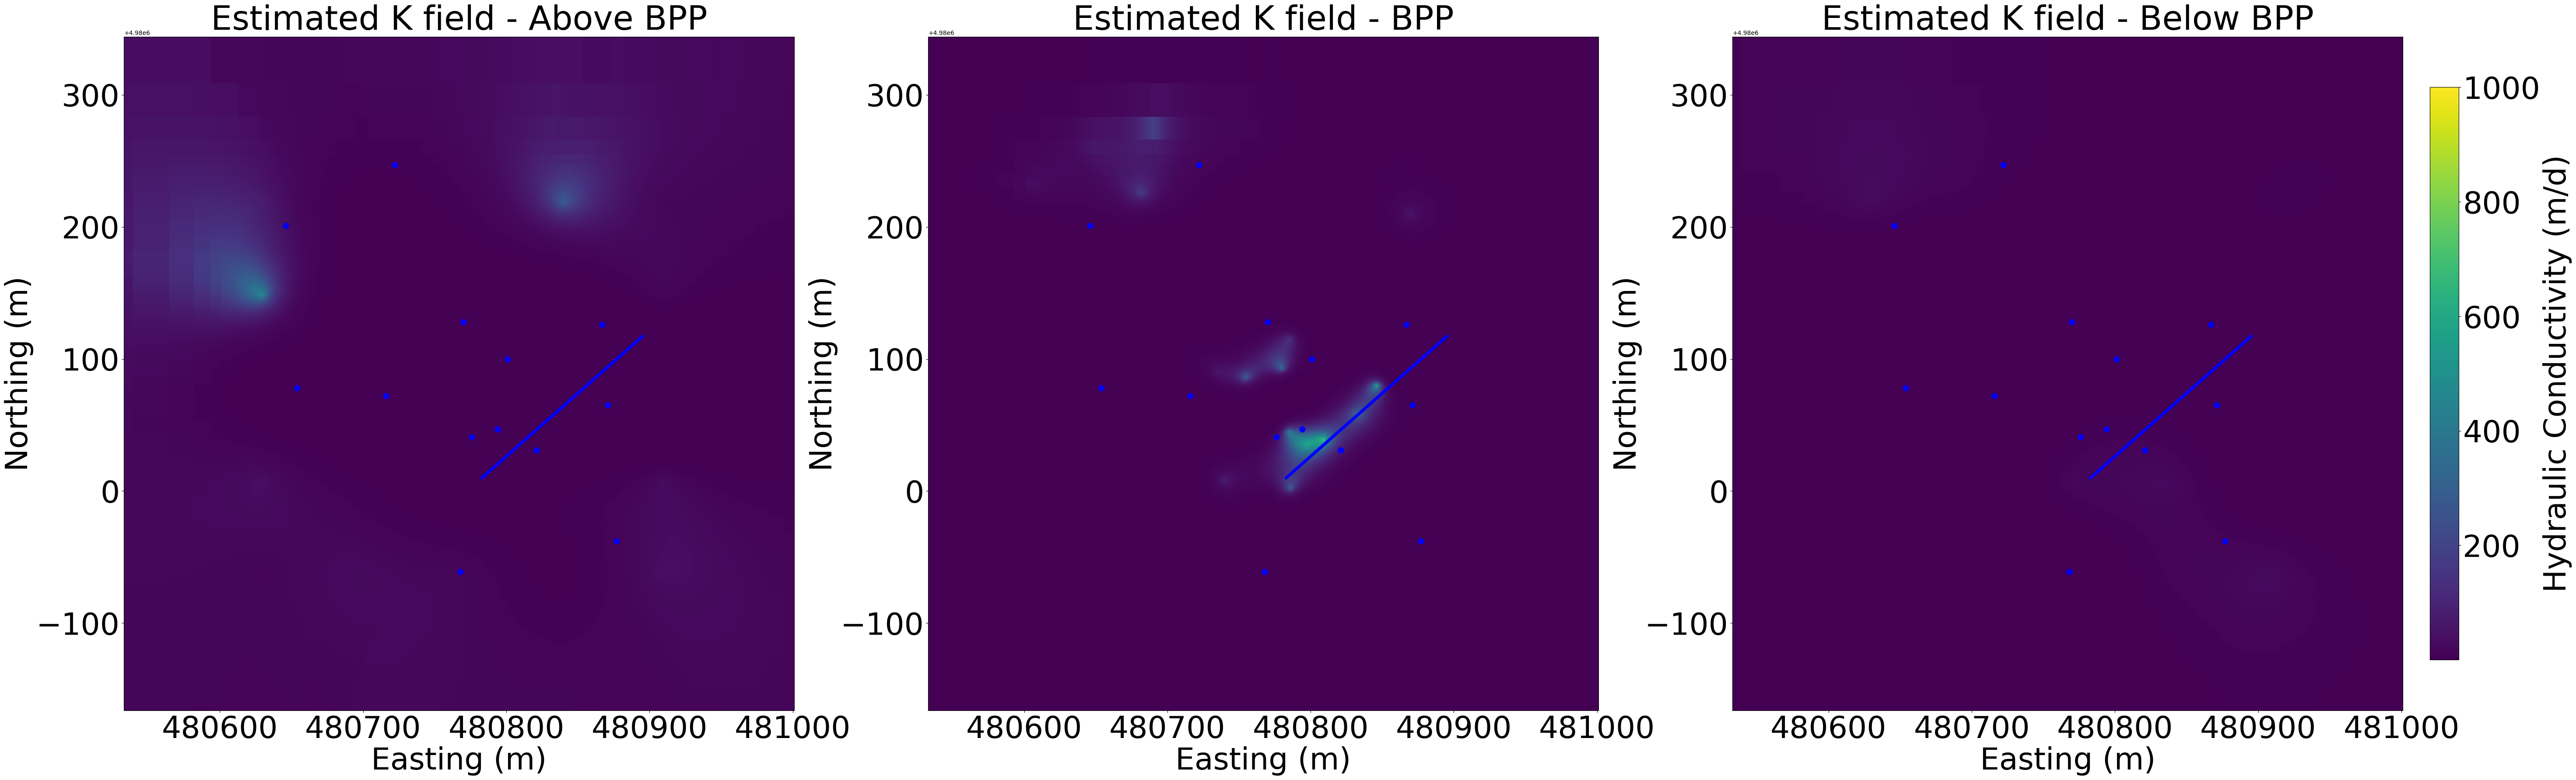

In [178]:
hk_array = gwf.npf.k.array
fig, axes = plt.subplots(1, 3, figsize=(80,20))

df = pd.read_csv("../../../data/wells_data.csv", index_col=0)
wells_site = df.loc[df.index != 'MLAC_center'].to_dict(orient='index')

wells_e = [coords['Easting'] for coords in wells_site.values()]
wells_n = [coords['Northing'] for coords in wells_site.values()]

wells = {
            'PMW-3': {
                'easting': 480770.0, 
                'northing': 4980127.0, 
                #'easting': x, 
                #'northing': y,
                'layer': 1, #second layer BPP (zero-indexed)
                'total_mass_mg': 2024.0
            }, 
            'horizontal_well': {
                'start_easting': 480895.0,
                'start_northing': 4980117.0,
                'end_easting': 480783.0,
                'end_northing': 4980010.0,
                #'start_easting': x_hz_start,
                #'start_northing': y_hz_start,
                #'end_easting': x_hz_end,
                #'end_northing': y_hz_end, 
                'layer': 1, #BPP layer
                'diameter_m': 0.1 #REVIEW THAT
            }
        }
# Optionally, determine common vmin and vmax for consistent color scaling
# These values MUST be positive for a log scale to work
#vmin = hk_array.min()
#vmax = hk_array.max()

vmin = 1.e-5
vmax = 1.e+3


labels = ['Above BPP', 'BPP', 'Below BPP']

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    
    # Pass the 'norm' object to plot_array()
    quadmesh = mapview.plot_array(hk_array[i], vmin=vmin, vmax=vmax)
    
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Estimated K field - {labels[i]}", fontsize=55)
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    
    ax.scatter(wells_e, wells_n, marker="o", color="blue", label="wells", s=80)
    ax.plot([wells["horizontal_well"]["start_easting"], wells["horizontal_well"]["end_easting"]], 
             [wells["horizontal_well"]["start_northing"], wells["horizontal_well"]["end_northing"]], 
             'blue', label="Hz well", linewidth=5)
    
    ax.set_xlabel("Easting (m)", fontsize=50)
    ax.set_ylabel("Northing (m)", fontsize=50)
    ax.tick_params(labelsize=50)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
# The colorbar automatically uses the norm associated with the quadmesh
cbar = fig.colorbar(quadmesh_list[0], ax=axes, pad=0.01, shrink=0.85, label="Hydraulic Conductivity (m/d)")
#cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=22)
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=50)
cbar.ax.tick_params(labelsize=50)
#fig.suptitle("No priors case", fontsize=40, y=1.02)

plt.show()

In [78]:
from matplotlib.colors import LogNorm 

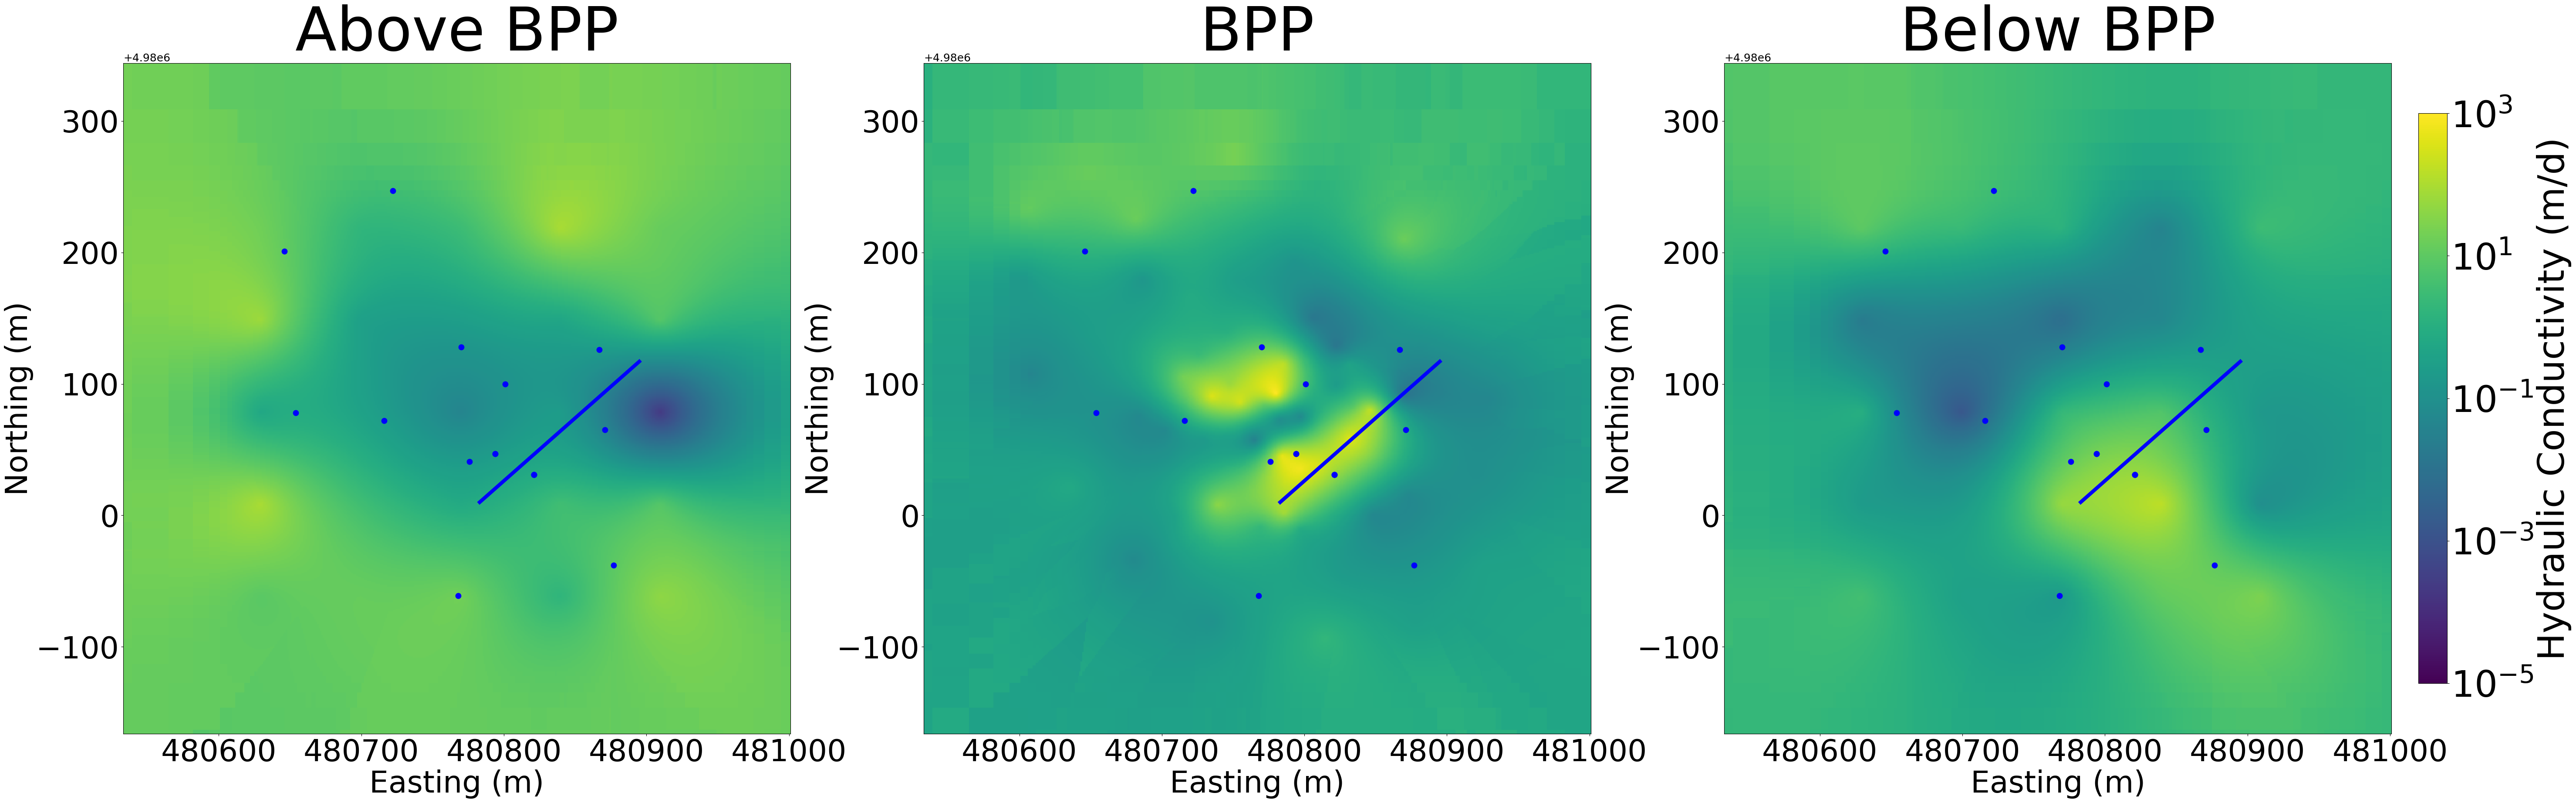

In [209]:
hk_array = gwf.npf.k.array
fig, axes = plt.subplots(1, 3, figsize=(80,20))

df = pd.read_csv("../../../data/wells_data.csv", index_col=0)
wells_site = df.loc[df.index != 'MLAC_center'].to_dict(orient='index')

wells_e = [coords['Easting'] for coords in wells_site.values()]
wells_n = [coords['Northing'] for coords in wells_site.values()]

wells = {
            'PMW-3': {
                'easting': 480770.0, 
                'northing': 4980127.0, 
                #'easting': x, 
                #'northing': y,
                'layer': 1, #second layer BPP (zero-indexed)
                'total_mass_mg': 2024.0
            }, 
            'horizontal_well': {
                'start_easting': 480895.0,
                'start_northing': 4980117.0,
                'end_easting': 480783.0,
                'end_northing': 4980010.0,
                #'start_easting': x_hz_start,
                #'start_northing': y_hz_start,
                #'end_easting': x_hz_end,
                #'end_northing': y_hz_end, 
                'layer': 1, #BPP layer
                'diameter_m': 0.1 #REVIEW THAT
            }
        }
# Optionally, determine common vmin and vmax for consistent color scaling
# These values MUST be positive for a log scale to work
#vmin = hk_array.min()
#vmax = hk_array.max()

vmin = 1.e-5
vmax = 1.e+3

# Ensure vmin is greater than 0, which hydraulic conductivity should be
if vmin <= 0:
    print(f"Warning: vmin ({vmin}) is <= 0. Adjusting to a small positive value for log scaling.")
    vmin = 1e-3 # Or some other appropriate small positive number

# Define the logarithmic normalization object
norm = LogNorm(vmin=vmin, vmax=vmax)

labels = ['Above BPP', 'BPP', 'Below BPP']

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    
    # Pass the 'norm' object to plot_array()
    quadmesh = mapview.plot_array(hk_array[i], norm=norm) 
    
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"{labels[i]}", fontsize=100)
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    
    ax.scatter(wells_e, wells_n, marker="o", color="blue", label="wells", s=80)
    ax.plot([wells["horizontal_well"]["start_easting"], wells["horizontal_well"]["end_easting"]], 
             [wells["horizontal_well"]["start_northing"], wells["horizontal_well"]["end_northing"]], 
             'blue', label="Hz well", linewidth=6)
    
    ax.set_xlabel("Easting (m)", fontsize=50)
    ax.set_ylabel("Northing (m)", fontsize=50)
    ax.tick_params(labelsize=50)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
# The colorbar automatically uses the norm associated with the quadmesh
cbar = fig.colorbar(quadmesh_list[0], ax=axes, pad=0.01, shrink=0.85, label="Hydraulic Conductivity (m/d)")
#cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=22)
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=60)
cbar.ax.tick_params(labelsize=60)
#fig.suptitle("No priors case", fontsize=40, y=1.02)
#plt.tight_layout()
plt.show()

In [186]:
hk_array_prior = gwf.npf.k.array

In [205]:
hk_array_no_prior = gwf.npf.k.array

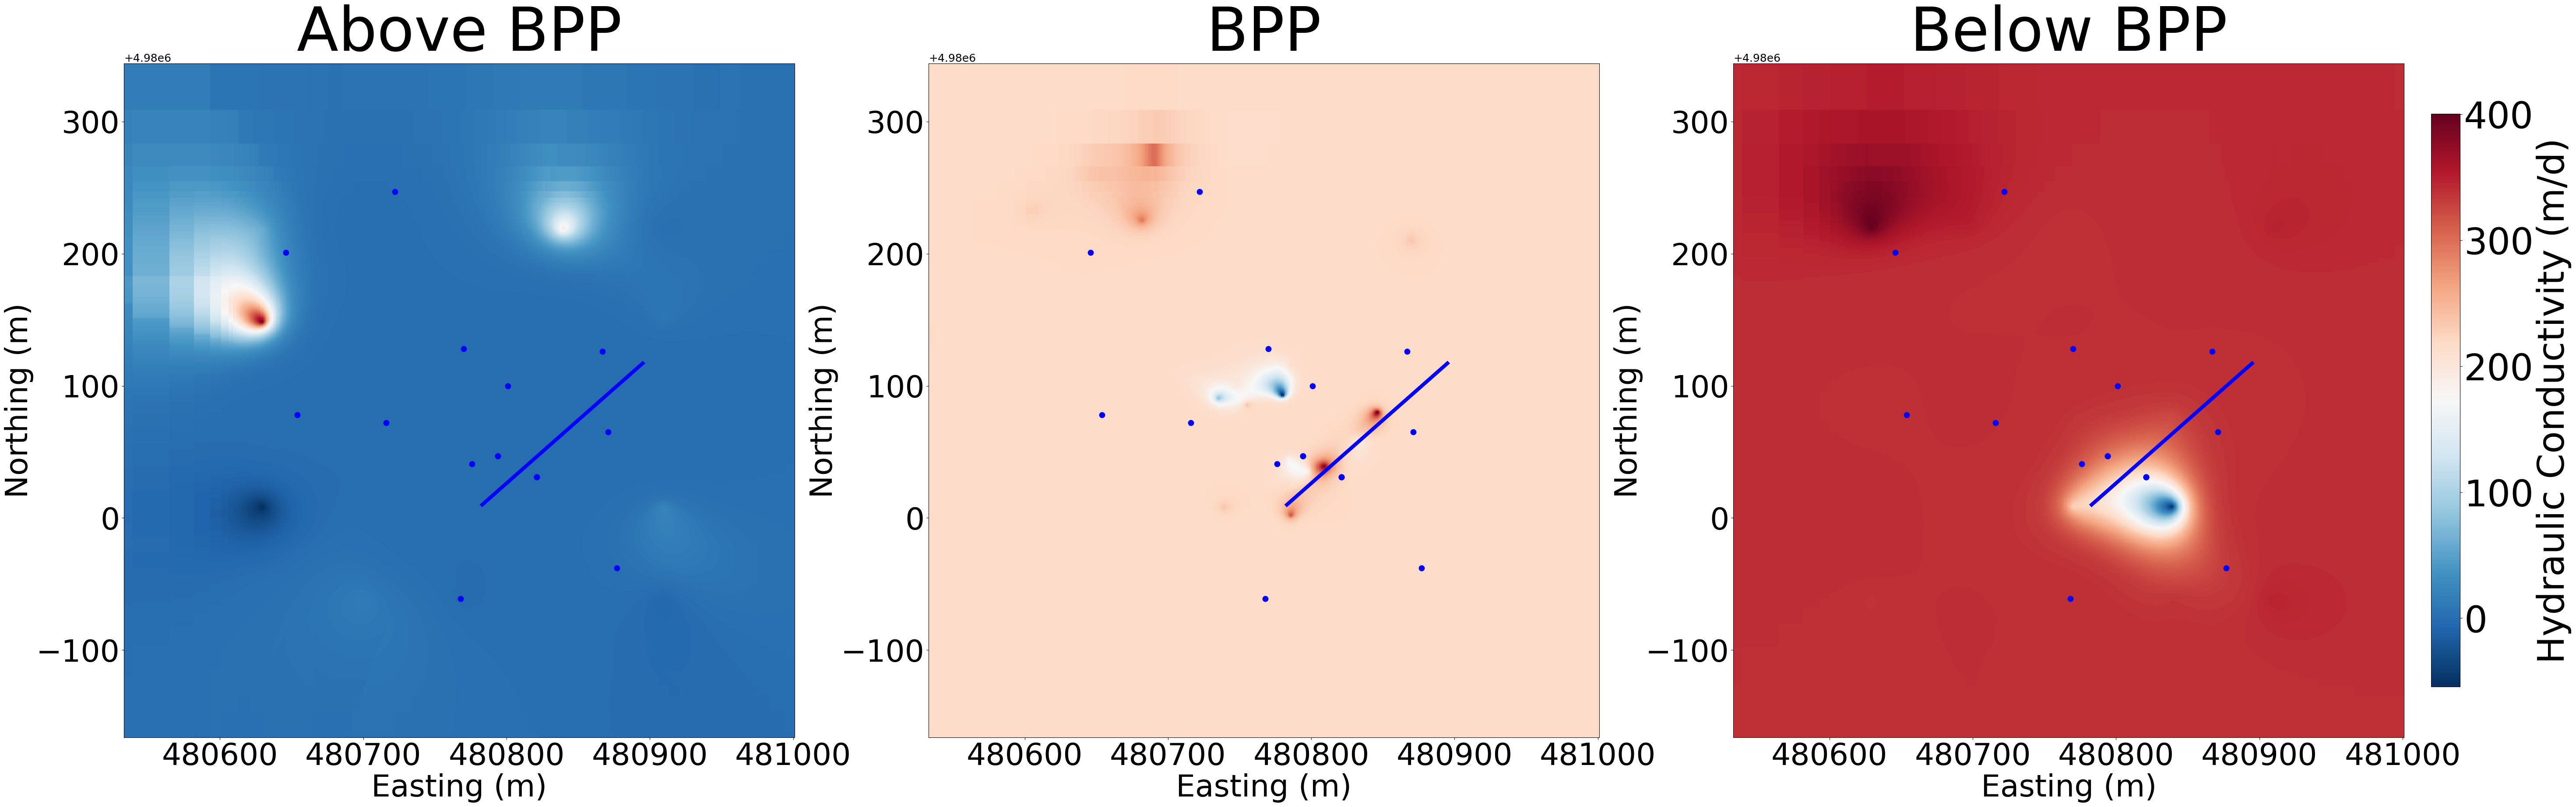

In [215]:
#hk_array = gwf.npf.k.array
fig, axes = plt.subplots(1, 3, figsize=(80,20))

df = pd.read_csv("../../../data/wells_data.csv", index_col=0)
wells_site = df.loc[df.index != 'MLAC_center'].to_dict(orient='index')

wells_e = [coords['Easting'] for coords in wells_site.values()]
wells_n = [coords['Northing'] for coords in wells_site.values()]

wells = {
            'PMW-3': {
                'easting': 480770.0, 
                'northing': 4980127.0, 
                #'easting': x, 
                #'northing': y,
                'layer': 1, #second layer BPP (zero-indexed)
                'total_mass_mg': 2024.0
            }, 
            'horizontal_well': {
                'start_easting': 480895.0,
                'start_northing': 4980117.0,
                'end_easting': 480783.0,
                'end_northing': 4980010.0,
                #'start_easting': x_hz_start,
                #'start_northing': y_hz_start,
                #'end_easting': x_hz_end,
                #'end_northing': y_hz_end, 
                'layer': 1, #BPP layer
                'diameter_m': 0.1 #REVIEW THAT
            }
        }
# Optionally, determine common vmin and vmax for consistent color scaling
# These values MUST be positive for a log scale to work
#vmin = hk_array.min()
#vmax = hk_array.max()

vmin = 1.e-5
vmax = 1.e+3

# Ensure vmin is greater than 0, which hydraulic conductivity should be
if vmin <= 0:
    print(f"Warning: vmin ({vmin}) is <= 0. Adjusting to a small positive value for log scaling.")
    vmin = 1e-3 # Or some other appropriate small positive number

# Define the logarithmic normalization object
norm = LogNorm(vmin=vmin, vmax=vmax)

labels = ['Above BPP', 'BPP', 'Below BPP']

# Plot each layer
quadmesh_list = []
max_val = (hk_array_prior - hk_array_no_prior).max()
min_val = (hk_array_prior - hk_array_no_prior).min()
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    
    # Pass the 'norm' object to plot_array()
    '''quadmesh = mapview.plot_array(hk_array_prior[i]-hk_array_no_prior[i],
                                   #norm=norm
                                   ) '''
    quadmesh = mapview.plot_array(hk_array_prior[i]-hk_array_no_prior[i], cmap='RdBu_r', 
                                  #norm=plt.Normalize(vmin=min_val, vmax=-min_val)
                                  )
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"{labels[i]}", fontsize=100)
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    
    ax.scatter(wells_e, wells_n, marker="o", color="blue", label="wells", s=80)
    ax.plot([wells["horizontal_well"]["start_easting"], wells["horizontal_well"]["end_easting"]], 
             [wells["horizontal_well"]["start_northing"], wells["horizontal_well"]["end_northing"]], 
             'blue', label="Hz well", linewidth=6)
    
    ax.set_xlabel("Easting (m)", fontsize=50)
    ax.set_ylabel("Northing (m)", fontsize=50)
    ax.tick_params(labelsize=50)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
# The colorbar automatically uses the norm associated with the quadmesh
cbar = fig.colorbar(quadmesh_list[0], ax=axes, pad=0.01, shrink=0.85, label="Hydraulic Conductivity (m/d)")
#cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=22)
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=60)
cbar.ax.tick_params(labelsize=60)
#fig.suptitle("No priors case", fontsize=40, y=1.02)
#plt.tight_layout()
plt.show()

debugging

In [216]:
lyr2['Kh (m/day)']

NameError: name 'lyr2' is not defined

In [212]:
max_val

np.float64(400.32770000000005)

In [1]:
import pathlib as pl 
import warnings
import flopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
